# Download and prepare `PPFD_IN` (2004-2025)

**notebook version**: `5` (31 Jul 2026)

## ℹ️ About this notebook

Downloads screened photosynthetic photon flux density `PPFD_IN` from InfluxDB, merges the sources
into one continuous series, applies the 2012 corrections and the nighttime zero-offset, gap-fills,
and writes the product to the external data folder.

Same shape as notebooks `01` (`SW_IN`) and `02` (`TA`), with two gap-filling differences noted in
*Method*. Like `01` it also carries a section establishing **which instrument the exported column
is** and what the two hardware changes did to it, because the fieldbook records a PAR sensor being
installed in January 2016 and that sensor is not this one.

**Output columns:**

- `PPFD_IN_T1_47_1_gfXG` — the gap-filled series (µmol m⁻² s⁻¹, complete, non-negative)
- `FLAG_PPFD_IN_T1_47_1_ISFILLED` — `0` = measured, `>0` = filled (codes in `FLAG_LEGEND` below)

**Notebook `01` has to be run first**: its gap-filled `SW_IN` is a driver here.

***

## 📇 Data sources

**Series**

- `PPFD_IN_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2004-2021), diive (2022-2025)
- **There is no NABEL PPFD sensor**, so unlike `SW_IN` and `TA` there is no second instrument of
  the same kind measured by another institution. Two radiation drivers stand in for it:
  - `SW_IN_T1_47_1_gfXG` — the gap-filled `SW_IN` from notebook `01`, complete over the whole
    record and physically almost proportional to `PPFD_IN`
  - `SW_IN_LAE_MS` — MeteoSwiss Lägern global radiation, 2.5 km away, read from the reference
    product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`. Independent of the tower,
    so it carries a real sky state where the tower `SW_IN` was itself gap-filled
- `PPFD_IN_T1_47_2` — ETH, 47 m, the **second** PAR sensor at the same height, mst only
  (2016-2021). Neither a driver nor an output: it is downloaded in the sensor-identity section
  below, where it is what separates the exported column from the sensor installed in January 2016
- Measurements start on **2004-09-20**; everything before that is filled — see the export section.

**Files beside the workflow folder**

- the GIN fieldbook export — the site's maintenance record, read in the sensor-identity section
- the CR10X (2004-2006) and CR1000 (2016) logger programs — what each era measured, and how its
  raw signal was converted

Legend:
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE
NIGHTTIME_THRESHOLD = 0.001  # SW_IN_POT below this counts as night, as in notebook 01

TARGET = "PPFD_IN_T1_47_1"

OUTNAME = "03_METEO_PPFD_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Gap-filled SW_IN produced by notebook 01, used here as the driver.
SWIN_FILE = "01_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"
SWIN_FLAG = "FLAG_SW_IN_T1_47_1_ISFILLED"

# Reference: MeteoSwiss Lägern global radiation, an independent second radiation driver. Produced
# by 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"

# --- Inputs for the sensor-identity section ----------------------------------------------------
# The second PAR sensor at 47 m. Downloaded there, not here, because it is neither a driver nor an
# output; it exists only to tell the two instruments apart.
SECOND_SENSOR = "PPFD_IN_T1_47_2"

# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every surviving logger program that measures incoming PAR at 47 m, read rather than quoted, so
# the sensor identity and the conversion are re-derived on every run. PROGRAMS_BF2 are the five
# CR10X programs carrying the Delta-T sensor; PROGRAM_BEFORE_BF2 is the one before them, which
# writes a DIFFERENT probe to the same storage location and is the reason this matters;
# PROGRAM_AFTER is the CR1000 program installed at the January 2016 changeover.
_CSI = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
        r"\csi_loggerscripts")
PROGRAMS_BF2 = [_CSI + r"\LAEGEREN.20040810.CSI",
                _CSI + r"\LAEGEREN.20041228.CSI",
                _CSI + r"\LAEGEREN.20050818.CSI",
                _CSI + r"\LAEGEREN.20050914.CSI",
                _CSI + r"\LAEGEREN.20060524.csi"]
PROGRAM_BEFORE_BF2 = _CSI + r"\LAEGEREN.20040526.CSI"
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-31 13:04:34
diive version: v0.91.0


In [3]:
# 0/1/2 are the standard diive gap-filling flags. 3 marks nighttime records set to zero by
# physics and 4 short gaps filled by interpolation, matching the codes used in notebooks 01/02.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = gap-filled by linear interpolation (short gap)',
}

### Captions

In [4]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 02.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below. (Notebooks 01, 02, 99 and the overview
    # carry the earlier version of this helper, which tests only for None and prints the caption
    # over the axis labels of every tight_layout figure; copy this one instead.)
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### Plot helpers

In [5]:
# Diagnostic plots for the gap-filling run. Defined once, used after it.
#
# Each helper writes its own caption, built from the arguments and the data it was handed rather
# than passed in as text. A second call site therefore cannot arrive without a caption, and one
# whose period or column changes cannot keep a caption describing the old one. Same rule as
# plot_product() in notebook 99 and the helpers in notebook 01.

def plot_gapfill_panels(gapfilled, flag, label, ylabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
                        figsize=(16, 7)):
    """Three stacked panels: measured only, the final series, and the fills on their own.

    The third panel is the one to look at. Fills are shown against a blank background, so a fill
    that sits at the wrong level, or a block of fills where there should be none, is immediately
    visible instead of being hidden under the measured series.
    """
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=f"{label}: measured, gap-filled, fills only", legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    fig = axs[0].get_figure()
    _blocks = int(((flag > 0) & ~(flag > 0).shift(1, fill_value=False)).sum())
    figcap(fig, f"{label}. Top: the measured records alone, so the gaps are visible as gaps. "
                f"Middle: the exported series, complete. Bottom: only the "
                f"{int((flag > 0).sum()):,} filled records ({100 * (flag > 0).mean():.1f} % of "
                f"the record), drawn against a blank background - a fill at an implausible level, "
                f"or a block of fills where there should be none, is visible here and nowhere "
                f"else. They fall in {_blocks:,} runs, dominated by the pre-record period of 2004 "
                f"at the left and by a small number of outages; this record has no scattered "
                f"background of single filled half-hours, so filtering on the flag removes whole "
                f"periods rather than a sprinkling.")
    return fig


def plot_pred_vs_measured(model, label, unit=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals.

    This is the only honest validation view available: `gapfilled` equals the measurement wherever
    the flag is 0, so plotting those against each other would just draw the 1:1 line.
    """
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))
    bias = float(residual.mean())
    # Half of this series is nighttime zeros, which any model predicts exactly, so an RMSE over
    # all held-out records is not the error a user of a daytime value should expect. Both are
    # reported; the daylight one is the honest number.
    _day = measured > 20
    rmse_day = float(np.sqrt((residual[_day] ** 2).mean()))

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{label}  (held-out test set, n={len(test):,})", fontsize=13)
    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}')
    axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {bias:+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)
    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}')
    axs[1].set_ylabel(f'residual (predicted - measured) {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    figcap(fig, f"the {label} against the {len(test):,} records held out of its own training, "
                f"which is the only view here that is not partly a restatement of the fit - "
                f"everywhere the flag is 0 the gap-filled series equals the measurement, so "
                f"plotting those against each other would draw the 1:1 line and say nothing. "
                f"Left: predicted against measured, with the 1:1 line. The RMSE over all "
                f"held-out records is {rmse:.0f} umol m-2 s-1 and the bias {bias:+.1f}, but half "
                f"of those records are nighttime zeros that any model gets exactly right; over "
                f"the {int(_day.sum()):,} daylight records alone the RMSE is "
                f"{rmse_day:.0f} umol m-2 s-1, which is the number to judge a fill by. Right: "
                f"the residual against the prediction. A tilt would mean the model is biased at "
                f"one end of the range. The spread widens away from zero and then stays broadly "
                f"constant, with scattered outliers at every level - most likely half-hours of "
                f"broken cloud, where the light at the sensor and the light at its drivers do "
                f"not have to agree.")
    return fig


def plot_feature_importances(results, label, top=12):
    """The drivers the model actually used, as a bar chart rather than only a table.

    A gap-filling model that leans almost entirely on the timestamp features is filling with
    climatology, whatever its scores say. This is the view that shows it at a glance.
    """
    imp = results.feature_importances.copy()
    _col = next((c for c in ('PERM_IMPORTANCE', 'IMPORTANCE', 'importance')
                 if c in imp.columns), imp.columns[0])
    imp = imp.sort_values(_col, ascending=False).head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(imp) + 1.6), dpi=100, layout='constrained')
    ax.barh(imp.index.astype(str), imp[_col], color='#1565C0')
    ax.set_xlabel(_col)
    ax.set_title(f'Driver importance: {label}', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    figcap(fig, f"the {min(top, len(imp))} most important drivers of the {label}, ranked by "
                f"{_col}. The strongest is {str(imp.index[-1])}. What matters here is whether a "
                f"real radiation measurement leads: a model that leans mainly on the timestamp "
                f"features is producing climatology rather than weather, whatever its held-out "
                f"scores say.")
    return fig


def fill_stats_by_year(flag, label, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')], errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4),
                         title='Filled records per year')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
        _worst = filled.sum(axis=1).idxmax()
        _totals = filled.sum(axis=1)
        _quiet = int((_totals < 100).sum())
        _first = flag.index[flag == 0][0]
        _pre = int(((flag.index < _first) & (flag.index.year == _worst)).sum())
        figcap(ax.get_figure(),
               f"filled records per year and method for {label}, measured records omitted so the "
               f"fills are readable. The most heavily filled year is {_worst} with "
               f"{int(_totals.max()):,} filled records, of which {_pre:,} precede the first "
               f"measured record. The fills are otherwise confined to a handful of "
               f"outage years: {_quiet} of the {len(_totals)} years carry fewer than a hundred "
               f"filled records each, and several carry none at all.")
    tabcap(f"records per year and provenance code for {label}. Every record carries a code, so "
           f"the rows sum to the number of half-hours in each year")
    return tab


def plot_fill_overview(series, flag, label, ylabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$'):
    """Three panels on the final series: where the fills are and whether they behave.

    Panels: the flag over date and time of day; monthly means of the full series against the
    measured-only series (a systematic gap between the two lines means the fills are biased); and
    the share of filled records per month.
    """
    fig = plt.figure(figsize=(18, 9), dpi=100, layout='constrained')
    gs = gridspec.GridSpec(2, 2, figure=fig)
    fig.suptitle(f'Gap-filling overview: {label}', fontsize=15)

    ax = fig.add_subplot(gs[:, 0])
    dv.plotting.HeatmapDateTime(series=flag.astype(float)).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='flag',
        format_style=dv.plotting.FormatStyle(title='Flag (0 = measured)', title_fontsize=11))

    measured = series.where(flag == 0)
    ax = fig.add_subplot(gs[0, 1])
    series.resample('MS').mean().plot(ax=ax, label='all records', lw=1.2)
    measured.resample('MS').mean().plot(ax=ax, label='measured only', lw=1.2, ls='--')
    ax.set_title('Monthly means', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    share = (flag > 0).resample('MS').mean() * 100
    ax.fill_between(share.index, share.values, step='mid', alpha=.7)
    ax.set_title('Share of filled records per month', fontsize=11)
    ax.set_ylabel('%')

    _monthly_gap = (series.resample('MS').mean() - measured.resample('MS').mean()).abs()
    _gap = _monthly_gap.max()
    _gap_month = _monthly_gap.idxmax()
    _rest = _monthly_gap.drop(index=_monthly_gap.index[_monthly_gap.index.year
                                                       == _gap_month.year]).max()
    figcap(fig, f"where the fills of {label} sit in the record and how they behave. Left: the "
                f"provenance code by date and time of day. The one extended block is at the foot "
                f"of the panel, before the measurement begins, where the nighttime hours carry "
                f"the zero code and the daylight hours the model code; everything above it is "
                f"measured apart from a small number of horizontal lines, each an outage spanning "
                f"all hours of a few days. Top right: monthly means of the complete series "
                f"against the measured records alone. The two part by {_gap:.0f} umol m-2 s-1 in "
                f"{_gap_month:%b %Y} and by at most {_rest:.0f} in any month outside that year; a "
                f"systematic separation would mean the fills are biased relative to the "
                f"measurements. Bottom right: the share of each month that is filled, which is "
                f"where the pre-record period and the individual outages appear.")
    return fig

### 🔌 Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

`mst` covers 2004-2021, `diive` covers 2022-2025. They do not overlap.

In [7]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PPFD']

mst_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2004-01-01 00:00:01', stop='2022-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_mst')

diive_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2022-01-01 00:00:01', stop='2026-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive')

mst_ppfd = TimestampSanitizer(data=mst_ppfd, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()
diive_ppfd = TimestampSanitizer(data=diive_ppfd, output_middle_timestamp=True,
                                nominal_freq=REQUIRED_TIME_RESOLUTION).get()
print(f"mst:   {mst_ppfd[TARGET].notna().sum():,} records")
print(f"diive: {diive_ppfd[TARGET].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_diive'], between 2022-01-01 00:00:01 and 2026-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

mst:   300,291 records
diive: 70,046 records
CPU times: total: 6.88 s
Wall time: 11.2 s


### Merge onto one continuous 30MIN index

In [8]:
full_index = pd.date_range('2004-01-01 00:15:00', '2025-12-31 23:45:00', freq='30min',
                           name='TIMESTAMP_MIDDLE')
ppfd_2004_2025 = pd.DataFrame(index=full_index)
ppfd_2004_2025[TARGET] = (mst_ppfd[TARGET]
                          .combine_first(diive_ppfd[TARGET])
                          .reindex(full_index))
print(f"{TARGET}: {ppfd_2004_2025[TARGET].notna().sum():,} of {len(ppfd_2004_2025):,} records")
print(f"first measurement: {ppfd_2004_2025[TARGET].first_valid_index()}")
tabcap("the merged series on one continuous 30MIN index, and the first rows of it. `mst` covers 2004-2021 and `diive` 2022-2025, and they do not overlap, so combine_first is a join of two screenings of one measurement rather than a gap-fill")
ppfd_2004_2025

PPFD_IN_T1_47_1: 370,337 of 385,728 records
first measurement: 2004-09-20 10:45:00
Table - the merged series on one continuous 30MIN index, and the first rows of it. `mst` covers
2004-2021 and `diive` 2022-2025, and they do not overlap, so combine_first is a join of two
screenings of one measurement rather than a gap-fill



,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### Heatmap

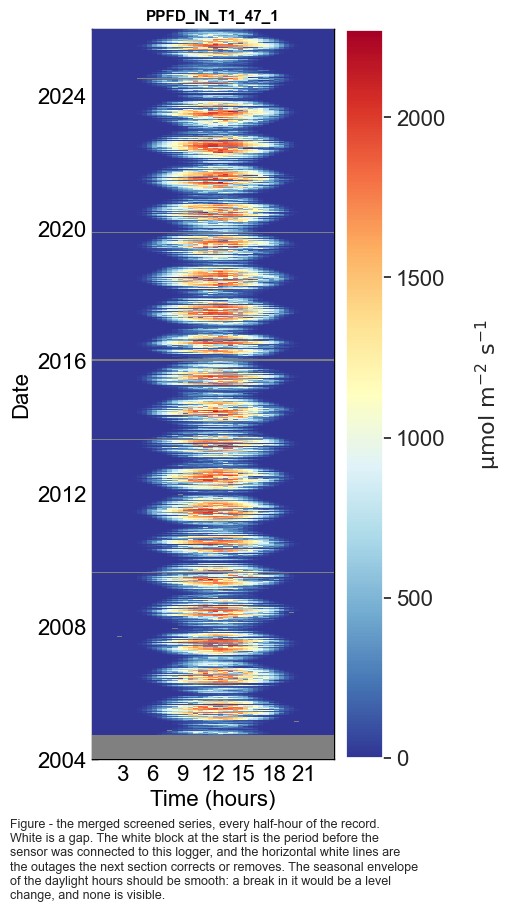

In [9]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=ppfd_2004_2025[TARGET]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))
figcap(fig, "the merged screened series, every half-hour of the record. White is a gap. The "
            "white block at the start is the period before the sensor was connected to this "
            "logger, and the horizontal white lines are the outages the next section "
            "corrects or removes. The seasonal envelope of the daylight hours should be "
            "smooth: a break in it would be a level change, and none is visible.")

***

## ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

A logger clock error affects every variable that logger recorded. `PPFD_IN` shows the same
`+15.5 h` shift as `SW_IN` and `TA` on 10-16 August, so the same correction is applied.

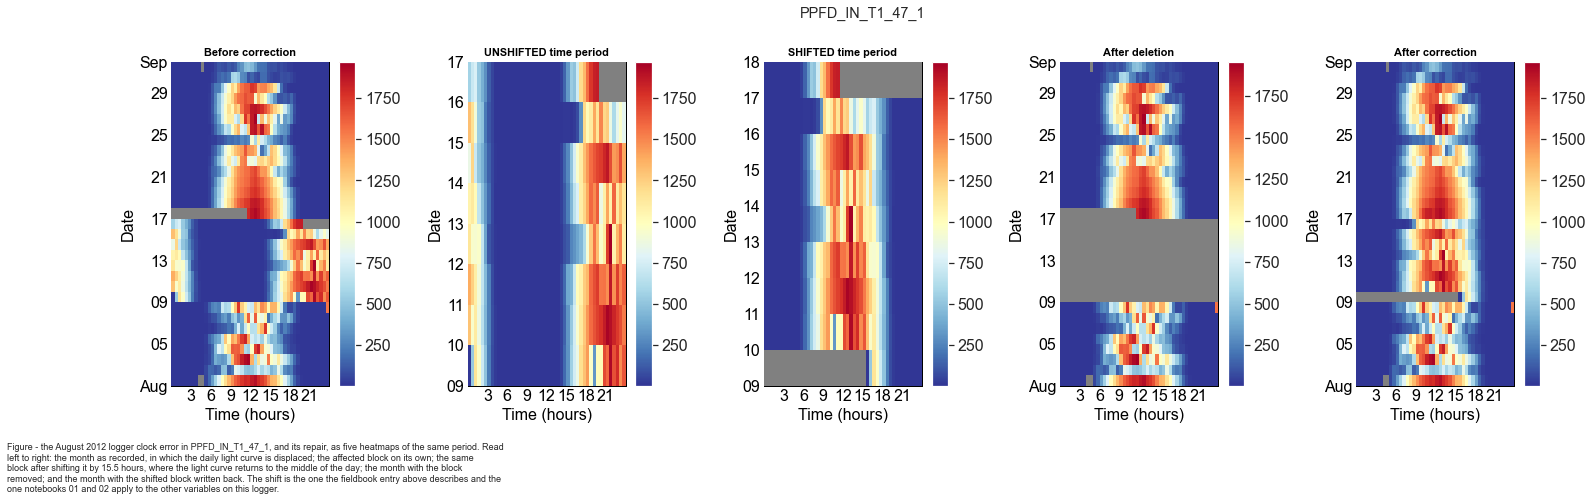

In [10]:
AFFECTED_VARS = [TARGET]
_df = ppfd_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before, ax_unshifted, ax_shifted, ax_after, ax_corrected = [
        fig.add_subplot(gs[0, i]) for i in range(5)]

    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy().dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))
    figcap(fig, f"the August 2012 logger clock error in {av}, and its repair, as five "
                f"heatmaps of the same period. Read left to right: the month as recorded, "
                f"in which the daily light curve is displaced; the affected block on its "
                f"own; the same block after shifting it by 15.5 hours, where the light "
                f"curve returns to the middle of the day; the month with the block removed; "
                f"and the month with the shifted block written back. The shift is the one "
                f"the fieldbook entry above describes and the one notebooks 01 and 02 apply "
                f"to the other variables on this logger.")

In [11]:
ppfd_2004_2025 = _df.copy()
tabcap("the series after the August 2012 clock error has been shifted back onto the correct time axis")
ppfd_2004_2025

Table - the series after the August 2012 clock error has been shifted back onto the correct time
axis



,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### Power failure and storm damage, 2012

The same three damaged windows removed in notebooks `01` and `02` apply to `PPFD_IN` as well.
Aligning `PPFD_IN` against the NABEL `SW_IN` sensor (the only instrument at the site not on the
affected logger) day by day, after scaling PPFD to W m-2 equivalent so the errors are comparable:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 49 | 49 |
| 2012-08-02 | 0 | 199 | 199 |
| 2012-08-09 | -32.5 h | 151 | 462 |
| **2012-08-11** | **+15.5 h** | **48** | 572 |
| **2012-08-16** | **+15.5 h** | **78** | 460 |
| 2012-08-18 | 0 | 34 | 34 |
| 2012-10-27 | 0 | 11 | 11 |
| 2012-10-30 | -24.0 h | 178 | 210 |
| 2012-11-05 | -24.0 h | 146 | 172 |
| 2012-11-11 | 0 | 6 | 6 |

The picture matches `SW_IN` and `TA` exactly: a clean `+15.5 h` clock offset on 10-16 August
(fixed by the correction above), an unrepairable degradation from 29 July to 9 August, and a
second unrepairable period from late October to early November. The fieldbook attributes the
first to a tower power supply failure repaired on 9 August, and the second to storm damage with
cable work on 6 November. Notebooks `01` and `02` document the evidence in full.

Windows are on the **corrected** time axis and are identical to those used there.

Removed 1213 degraded records from PPFD_IN_T1_47_1 (gap-filled later).


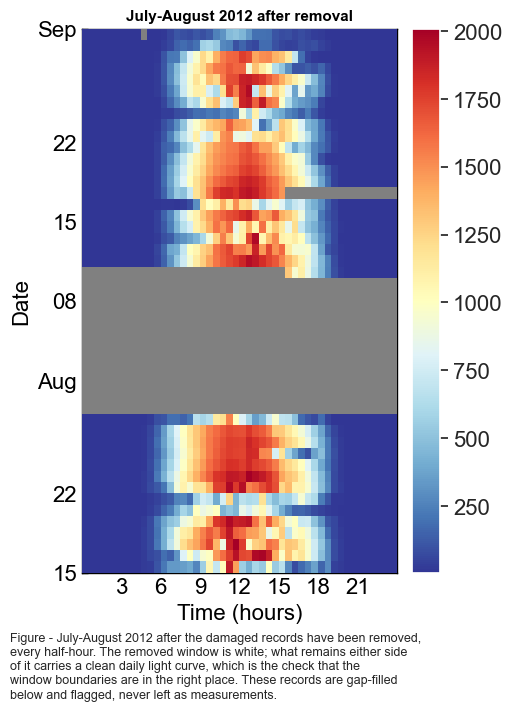

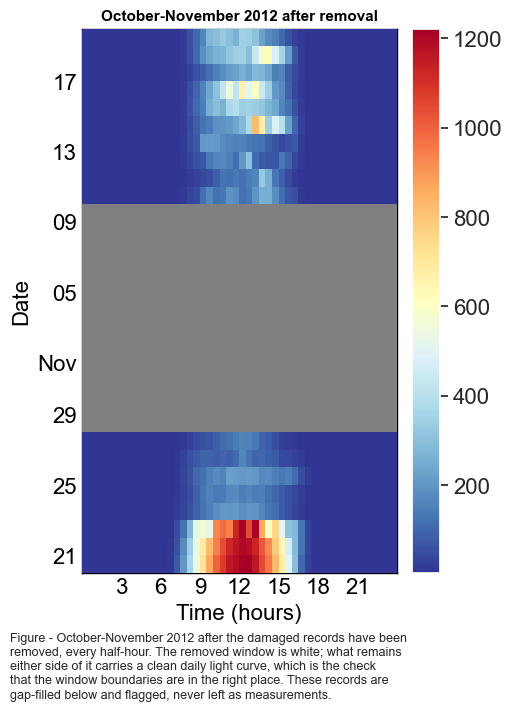

In [12]:
# Identical to the windows removed in notebooks 01 and 02 - the faults are in the logger and
# the power supply, so every variable on that system is affected.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_before = int(ppfd_2004_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (ppfd_2004_2025.index >= _start) & (ppfd_2004_2025.index <= _end)
    ppfd_2004_2025.loc[_locs, TARGET] = np.nan
_removed = _before - int(ppfd_2004_2025[TARGET].notna().sum())
print(f"Removed {_removed} degraded records from {TARGET} (gap-filled later).")

for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, ax = plt.subplots(figsize=(5, 7), dpi=100, layout="constrained")
    _show = (ppfd_2004_2025.index >= _lo) & (ppfd_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=ppfd_2004_2025.loc[_show, TARGET]).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(
            title=f'{_label} 2012 after removal', title_fontsize=11))
    figcap(fig, f"{_label} 2012 after the damaged records have been removed, every "
                f"half-hour. The removed window is white; what remains either side of it "
                f"carries a clean daily light curve, which is the check that the window "
                f"boundaries are in the right place. These records are gap-filled below "
                f"and flagged, never left as measurements.")

### Nighttime zero-offset

`PPFD_IN` must read zero at night. A sensor that does not is carrying an offset, which
`dv.corrections.remove_nighttime_zero_offset` removes: for each day it takes the mean of that
day's nighttime values as the offset, subtracts it from the whole day, then sets nighttime to
zero and clamps the remaining negatives to zero. It is the same routine notebook `01` applies to
`SW_IN` through `correct_nighttime_offset=True`, called directly here because `PPFD_IN` has no
dedicated gap-filling class.

**The gap mask has to be taken before this step.** The correction sets every nighttime record to
zero, and it does not distinguish a nighttime measurement from a nighttime gap — the missing ones
become zero too. Asking the corrected series which records are missing therefore reports no
nighttime gaps at all, and they would be exported as `0 = observed` when they are really fills.
`PPFD_ORIGINAL_GAPS` is captured first and carried into the gap-filler, which flags them `3`.

gaps before correction: 16,604


> running remove_nighttime_zero_offset ...

before: min 0.00, records below zero: 0
after : min 0.00, records below zero: 0
mean change on measured records: -2.935 umol m-2 s-1
nighttime gaps zeroed by the correction: 7,543 (fills, not measurements - flagged 3 by the gap-filler)
Table - the series after the nighttime offset has been removed. The count is the whole record rather
than the measured records, because the correction has written a zero into every nighttime gap as
well



,PPFD_IN_T1_47_1
count,376667.000000
mean,284.502278
std,484.057175
min,0.000000
25%,0.000000
50%,2.655310
75%,358.031093
max,2271.086339


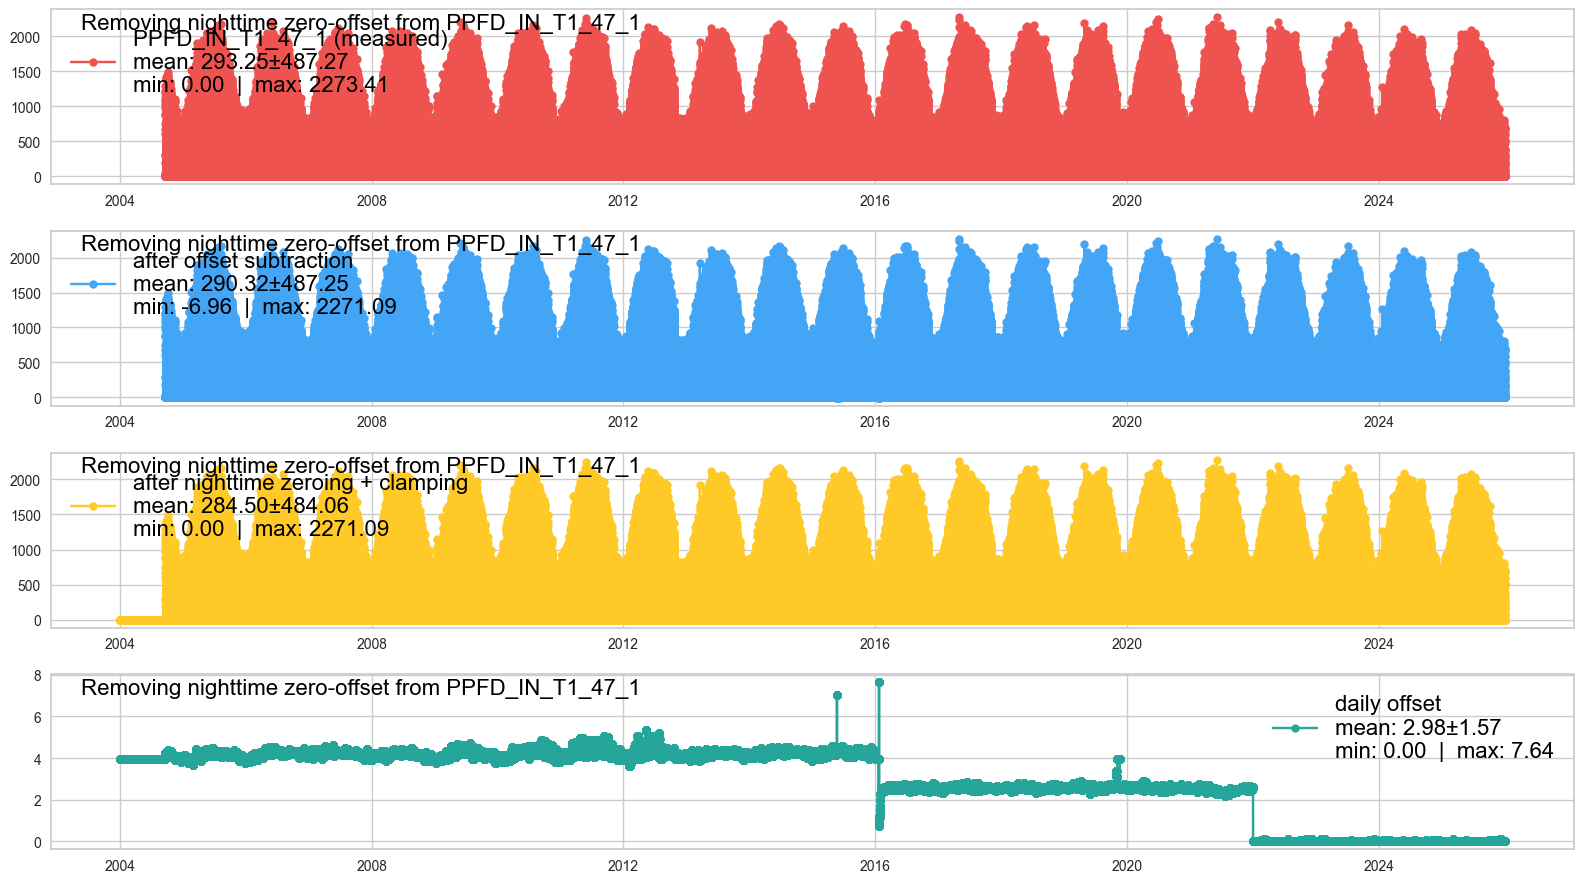

In [13]:
# Capture the gap mask BEFORE correcting. remove_nighttime_zero_offset() sets EVERY
# nighttime record to zero, including the missing ones, so afterwards a nighttime gap is
# indistinguishable from a nighttime measurement. Without this mask those filled zeros
# would reach the export flagged 0 = observed.
PPFD_ORIGINAL_GAPS = ppfd_2004_2025[TARGET].isna()
print(f"gaps before correction: {int(PPFD_ORIGINAL_GAPS.sum()):,}")

ppfd_corrected = dv.corrections.remove_nighttime_zero_offset(
    series=ppfd_2004_2025[TARGET].copy(),
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    showplot=True, clamp_negatives=True,
)

# Kept for the figure below: after the assignment at the end of this cell the pre-correction
# series is otherwise unrecoverable.
PPFD_BEFORE_OFFSET = ppfd_2004_2025[TARGET].copy()
_before = PPFD_BEFORE_OFFSET
print(f"before: min {_before.min():.2f}, records below zero: {(_before < 0).sum():,}")
print(f"after : min {ppfd_corrected.min():.2f}, records below zero: {(ppfd_corrected < 0).sum():,}")
print(f"mean change on measured records: {float((ppfd_corrected - _before).mean()):+.3f} umol m-2 s-1")
print(f"nighttime gaps zeroed by the correction: "
      f"{int((PPFD_ORIGINAL_GAPS & ppfd_corrected.notna()).sum()):,} "
      f"(fills, not measurements - flagged 3 by the gap-filler)")

ppfd_2004_2025[TARGET] = ppfd_corrected
tabcap("the series after the nighttime offset has "
       "been removed. The count is the whole record rather than the measured records, "
       "because the correction has written a zero into every nighttime gap as well")
ppfd_2004_2025.describe()

#### Check: nighttime is zero and nothing is negative

The correction is checked against a day/night split rebuilt from the site coordinates rather than
against the one the correction itself used, so a routine that silently did nothing cannot be
confirmed by its own definition of night.

In [14]:
# Rebuild the day/night split independently of the correction, from the site coordinates, so the
# check does not use the same flag the correction did. A routine that silently did nothing would
# otherwise be confirmed by its own definition of night.
_dnf = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=ppfd_2004_2025.index, nighttime_threshold=NIGHTTIME_THRESHOLD,
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_night = _dnf.get_nighttime_flag() == 1
_measured_now = ppfd_2004_2025[TARGET].where(~PPFD_ORIGINAL_GAPS)

_bad_night = int((_measured_now[_night].dropna() != 0).sum())
_bad_neg = int((_measured_now < 0).sum())
print(f"measured nighttime records that are not exactly zero: {_bad_night}")
print(f"measured records below zero:                          {_bad_neg}")
assert _bad_night == 0, f'{_bad_night} measured nighttime records are not zero after the correction'
assert _bad_neg == 0, f'{_bad_neg} measured records are still negative after the correction'
print("Nighttime and negativity checks passed on the measured records.")

measured nighttime records that are not exactly zero: 0
measured records below zero:                          0
Nighttime and negativity checks passed on the measured records.


#### Plot: what the offset correction removed

The printout above gives the mean change over the record, which is one number for something that
is not one number. What the correction removes changes twice, and both changes are informative
about the acquisition system rather than about the light.

median daily nighttime offset, by acquisition and screening era (umol m-2 s-1):
  2004-2015: 4.19
  2016-2021: 2.55
  2022-2025: 0.00


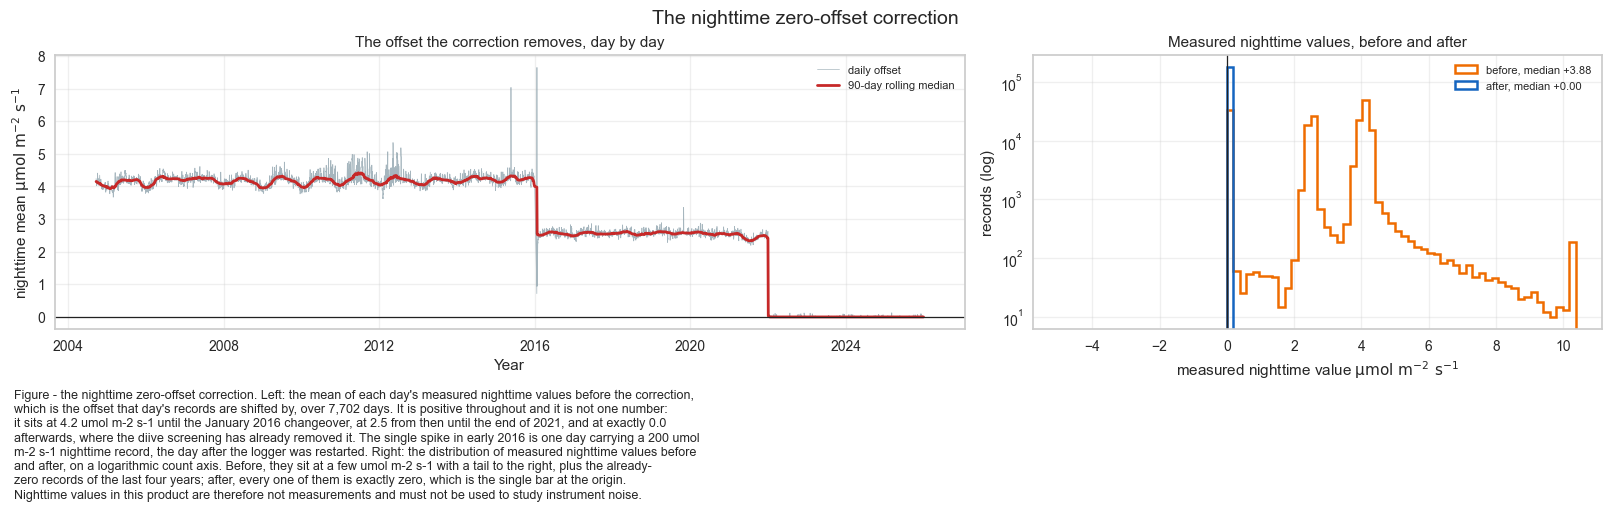

In [15]:
# What the correction removed, drawn. The printout above gives its mean over the record, which is
# one number for a quantity that is not one number: the offset is re-derived every day, and the
# reason it is removed per day rather than as a constant is visible here and nowhere else.
_offset_daily = PPFD_BEFORE_OFFSET.where(_night).resample('D').mean().dropna()

fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout='constrained',
                        width_ratios=[1.6, 1])
fig.suptitle('The nighttime zero-offset correction', fontsize=14)

axs[0].plot(_offset_daily.index, _offset_daily, color='#90A4AE', lw=0.5, alpha=0.8,
            label='daily offset')
axs[0].plot(_offset_daily.index, _offset_daily.rolling(90, center=True, min_periods=30).median(),
            color='#C62828', lw=2.0, label='90-day rolling median')
axs[0].axhline(0, color='#212121', lw=0.9)
axs[0].set_xlabel('Year')
axs[0].set_ylabel(r'nighttime mean $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
axs[0].set_title('The offset the correction removes, day by day', fontsize=11)
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3)

_nb = PPFD_BEFORE_OFFSET.where(_night).dropna()
_na = ppfd_2004_2025[TARGET].where(~PPFD_ORIGINAL_GAPS).where(_night).dropna()
_edges = np.linspace(min(-5, float(_nb.quantile(0.001))), max(5, float(_nb.quantile(0.999))), 81)
axs[1].hist(_nb.clip(_edges[0], _edges[-1]), bins=_edges, histtype='step', lw=1.8,
            color='#EF6C00', label=f'before, median {_nb.median():+.2f}')
axs[1].hist(_na.clip(_edges[0], _edges[-1]), bins=_edges, histtype='step', lw=1.8,
            color='#1565C0', label=f'after, median {_na.median():+.2f}')
axs[1].axvline(0, color='#212121', lw=0.9)
axs[1].set_yscale('log')
axs[1].set_xlabel(r'measured nighttime value $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
axs[1].set_ylabel('records (log)')
axs[1].set_title('Measured nighttime values, before and after', fontsize=11)
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3)

_eras = {'2004-2015': _offset_daily.loc[:'2015-12-31'].median(),
         '2016-2021': _offset_daily.loc['2016-02-01':'2021-12-31'].median(),
         '2022-2025': _offset_daily.loc['2022-01-01':].median()}
print("median daily nighttime offset, by acquisition and screening era "
      "(umol m-2 s-1):")
for _k, _v in _eras.items():
    print(f"  {_k}: {_v:.2f}")

figcap(fig, f"the nighttime zero-offset correction. Left: the mean of each day's measured "
            f"nighttime values before the correction, which is the offset that day's records are "
            f"shifted by, over {len(_offset_daily):,} days. It is positive throughout and it is "
            f"not one number: it sits at {_eras['2004-2015']:.1f} umol m-2 s-1 until the January "
            f"2016 changeover, at {_eras['2016-2021']:.1f} from then until the end of 2021, and "
            f"at exactly {_eras['2022-2025']:.1f} afterwards, where the diive screening has "
            f"already removed it. The single spike in early 2016 is one day carrying a 200 "
            f"umol m-2 s-1 nighttime record, the day after the logger was restarted. Right: the "
            f"distribution of measured nighttime values before and after, on a logarithmic count "
            f"axis. Before, they sit at a few umol m-2 s-1 with a tail to the right, plus the "
            f"already-zero records of the last four years; after, every one of them is exactly "
            f"zero, which is the single bar at the origin. Nighttime values in this product are "
            f"therefore not measurements and must not be used to study instrument noise.")

***

## 🟦 Drivers

`PPFD_IN` and `SW_IN` are two measurements of essentially the same flux in different units, so
the gap-filled `SW_IN` from notebook `01` is a far stronger driver than anything derived from the
timestamp. `SW_IN_POT` is added as well: it never has gaps and carries sun angle and season, which
is what separates a clear morning from a clear afternoon of equal `SW_IN`.

A third driver, **MeteoSwiss Lägern global radiation** (`SW_IN_LAE_MS`), is added below. The
tower `SW_IN` driver is complete only because notebook `01` gap-filled it; at those positions it
is a model output, and `PPFD_IN` gaps tend to coincide with `SW_IN` gaps (same faults). Lägern is
an independent measurement 2.5 km away, so it supplies a real sky state exactly where the tower
driver is weakest.

Because all three drivers span the whole record, there is **no need to split into periods**,
unlike notebooks `01` and `02` where the NABEL sensor stopped in 2018.

In [16]:
swin_gf = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{SWIN_FILE}.parquet"))
print(f"Loaded {SWIN_FILE}: {list(swin_gf.columns)}")

drivers = pd.DataFrame(index=ppfd_2004_2025.index)
drivers[SWIN_COL] = swin_gf[SWIN_COL]  # keeps the name it has in the file
drivers['SW_IN_POT'] = dv.variables.potrad(
    timestamp_index=ppfd_2004_2025.index, lat=SITE_LAT, lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)

print(drivers.isnull().sum().rename('missing values'))
tabcap("the two drivers available before the reference is added: the gap-filled tower "
       "SW_IN from notebook 01, and potential radiation computed from the site coordinates. "
       "Both are complete by construction, which is why neither on its own tells the model "
       "what the sky was doing")
drivers.describe()

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.758 seconds).

Loaded 01_METEO_SW_IN_GAPFILLED_2004-2025: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']


SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64
Table - the two drivers available before the reference is added: the gap-filled tower SW_IN from
notebook 01, and potential radiation computed from the site coordinates. Both are complete by
construction, which is why neither on its own tells the model what the sky was doing



,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000
mean,145.881536,298.951202
std,240.172173,382.633189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.033335,17.494992
75%,197.979111,566.632430
max,1118.658439,1214.125501


### 🌍 MeteoSwiss Lägern

Lägern global radiation, added to `drivers` as an independent second radiation predictor. It
carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`, so the index is shifted back 15
minutes (the midpoint of a 30MIN bin). The guard correlates it against the measured tower
`PPFD_IN` on daytime records — same physics, different units — and asserts offset 0 wins, so a
mis-shifted reference cannot silently teach the model the wrong daily cycle.

In [17]:
ppfd_ref = pd.read_parquet(REFPATH)[[REFCOL]]
ppfd_ref.index = ppfd_ref.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
ppfd_ref.index.name = ppfd_2004_2025.index.name

_meas = ppfd_2004_2025[TARGET]
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), ppfd_ref[REFCOL].shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

drivers[REFCOL] = ppfd_ref[REFCOL]
print(f"\n{REFCOL} available for {drivers[REFCOL].notna().mean() * 100:.2f}% of records")
tabcap("the three gap-filling drivers. The MeteoSwiss column is the only one with gaps of "
       "its own, and the only one that is a measurement independent of this tower")
drivers.describe()

  offset -1 x 30min: daytime corr 0.9252
  offset +0 x 30min: daytime corr 0.9629


  offset +1 x 30min: daytime corr 0.9077
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

SW_IN_LAE_MS available for 99.58% of records
Table - the three gap-filling drivers. The MeteoSwiss column is the only one with gaps of its own,
and the only one that is a measurement independent of this tower



,SW_IN_T1_47_1_gfXG,SW_IN_POT,SW_IN_LAE_MS
count,385728.000000,385728.000000,384126.000000
mean,145.881536,298.951202,141.513118
std,240.172173,382.633189,231.392431
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000
50%,4.033335,17.494992,5.333333
75%,197.979111,566.632430,189.333333
max,1118.658439,1214.125501,1155.333333


#### Plot: what the two drivers actually offer

`describe()` says the drivers cover comparable ranges. It does not say how tightly each one tracks
the target half-hour by half-hour, which is what determines how good a fill from it can be — and
the two differ in exactly that.

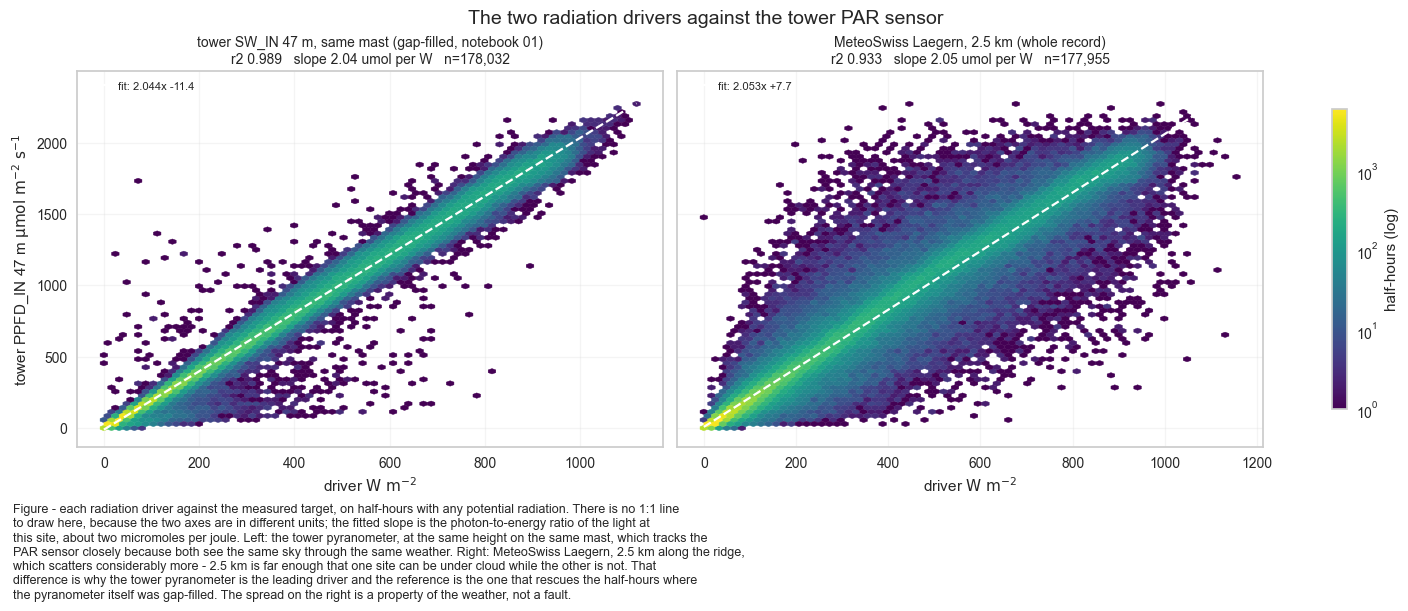

In [18]:
# Each driver against the target on well-lit half-hours. `describe()` above says the three series
# cover comparable ranges; it does not say how tightly each driver tracks the target half-hour by
# half-hour, which is what determines how good a fill from it can be.
_potrad_drv = drivers['SW_IN_POT']
_lit_drv = _potrad_drv > 50
_meas_drv = ppfd_2004_2025[TARGET].where(~PPFD_ORIGINAL_GAPS)

fig, axs = plt.subplots(ncols=2, figsize=(14, 6), dpi=100, layout='constrained', sharey=True)
fig.suptitle('The two radiation drivers against the tower PAR sensor', fontsize=14)

for _ax, _driver, _label in [
        (axs[0], SWIN_COL, 'tower SW_IN 47 m, same mast (gap-filled, notebook 01)'),
        (axs[1], REFCOL, 'MeteoSwiss Laegern, 2.5 km (whole record)')]:
    _j = pd.concat([_meas_drv.rename('t'), drivers[_driver].rename('d')], axis=1)[_lit_drv].dropna()
    _hb = _ax.hexbin(_j['d'], _j['t'], gridsize=70, mincnt=1, bins='log', cmap='viridis')
    _lim = [0, float(_j['d'].max())]
    _slope, _icpt = np.polyfit(_j['d'].to_numpy(), _j['t'].to_numpy(), 1)
    _ax.plot(_lim, [_slope * _x + _icpt for _x in _lim], color='w', lw=1.6, ls='--',
             label=f'fit: {_slope:.3f}x {_icpt:+.1f}')
    _r2 = _j['d'].corr(_j['t']) ** 2
    _ax.set_title(f"{_label}\nr2 {_r2:.3f}   slope {_slope:.2f} umol per W   n={len(_j):,}",
                  fontsize=10)
    _ax.set_xlabel(r'driver $\mathrm{W\ m^{-2}}$')
    _ax.legend(fontsize=8, loc='upper left')
    _ax.grid(alpha=0.2)
axs[0].set_ylabel(r'tower PPFD_IN 47 m $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
fig.colorbar(_hb, ax=axs, label='half-hours (log)', shrink=0.8)

figcap(fig, "each radiation driver against the measured target, on half-hours with any potential "
            "radiation. There is no 1:1 line to draw here, because the two axes are in different "
            "units; the fitted slope is the photon-to-energy ratio of the light at this site, "
            "about two micromoles per joule. Left: the tower pyranometer, at the same height on "
            "the same mast, which tracks the PAR sensor closely because both see the same sky "
            "through the same weather. Right: MeteoSwiss Laegern, 2.5 km along the ridge, which scatters "
            "considerably more - 2.5 km is far enough that one site can be under cloud while the "
            "other is not. That difference is why the tower pyranometer is the leading driver and "
            "the reference is the one that rescues the half-hours where the pyranometer itself "
            "was gap-filled. The spread on the right is a property of the weather, not a fault.")

***

## 🔎 Which sensor this is, and what the hardware changes did to it

On 21 January 2016 the tower's data logger was replaced, and notebook `02` established that
`TA_T1_47_1` steps by about 1.3 °C across that changeover. The same acquisition system carries
`PPFD_IN_T1_47_1`, and the fieldbook additionally records **a new Kipp & Zonen PAR sensor being
installed on 8 January 2016** — so for this variable the question is not only whether the series
moved, but whether the column is even the same instrument either side of that month.

**It is**, and the sensor installed that January is a different column. This section records what
establishes that, and then runs the same scan over the rest of the record rather than at one
candidate year, which turns up the one change in this series that is real:

1. **the exported column is the Delta-T sunshine sensor**, not the Kipp & Zonen PAR LITE — the
   CR1000 program measures both, under the two field names the database uses;
2. **the record begins after that sensor was installed**, which matters because the program before
   it writes a different probe, at a different multiplier, to the same storage location;
3. **the PAR LITE has its own column**, and that column begins at the changeover and never reaches
   back beyond it;
4. **the data show no step at January 2016** — smaller than the change the same measurement finds
   in an ordinary year;
5. **the two changes the same scan does find, in 2011 and 2013, are not this sensor** — one is the
   reference station and one is a separation between the two tower sensors that three series
   cannot resolve;
6. **and there is no step at the December 2021 screening splice** either;
7. **the fieldbook records no replacement and no calibration** of this sensor in twenty-one years;
8. **the sensor's response has been falling since 2021**, and the record ends without it having
   levelled off. This is the one finding here that is not a negative result, and it is a limitation of
   the exported product.

The full four-sensor attribution, which brings in the NABEL pyranometer at 49 m as a fourth
witness and is what places the decline on this sensor rather than on either reference, is in
`RADIATION_SENSOR_CONTINUITY.ipynb`. This section carries what bears on the product built here,
together with the assertions that keep it true.

### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so
that a re-run re-derives the argument instead of inheriting a stale copy of it. Both are signed by
the people who did the work and this notebook renders to a public page, so every string taken out
of either passes through the same redaction used in notebooks `01`, `02` and `08`.

In [19]:
# --- Fieldbook and logger-program redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 01, 02 and 08; the map lives beside the
# export, OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


_ARITHMETIC = re.compile(r'^[0-9.\s()*/+-]+$')


def program_constants(path) -> dict:
    """Every `Const <name> = <expression>` declared in a CR1000 program, evaluated.

    The CR1000 program does not write the PPFD multipliers as numbers. It writes them as the
    arithmetic that turns a calibration certificate into a multiplier - `1/5.65*1000` for a
    sensitivity of 5.65 uV per umol m-2 s-1 - and then names the result in the measurement
    instruction. Reading the instruction alone therefore yields a name and no number, so the
    declarations have to be parsed too.

    Only expressions made of digits, spaces, brackets and the four arithmetic operators are
    evaluated; anything else is skipped, so a program cannot make this cell run something. Raises
    if the file declares no constants at all, rather than returning an empty dict that would make
    every later lookup fail somewhere less informative.
    """
    text = Path(path).read_text(encoding='latin-1')
    out = {}
    for _name, _expr in re.findall(r'^\s*Const\s+(\w+)\s*=\s*([^\'\r\n]+)', text, re.M):
        _expr = _expr.strip()
        if not _ARITHMETIC.match(_expr):
            continue
        try:
            out[_name] = float(eval(_expr, {'__builtins__': {}}, {}))
        except (SyntaxError, ZeroDivisionError, TypeError):
            continue
    if not out:
        raise ValueError(f"{Path(path).name}: no numeric `Const` declaration found. This program "
                         f"language does not declare constants, or the layout has changed.")
    return out


def calibration_constants(excerpt: str, consts: dict | None = None) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    Three shapes occur across the two program languages and both are matched on their own terms:
    the CR10X lists the two numbers as numbered parameters, while the CR1000 passes them as the
    last two arguments of a `VoltSe(...)` or `VoltDiff(...)` call. In the CR1000 an argument may be
    the *name* of a declared constant rather than a literal, which is why `consts` exists.

    Raises if either number cannot be found or a name cannot be resolved. A silently empty result
    would make the comparison below pass by having nothing to disagree about, and an unresolved
    name would do the same.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        _m = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        _o = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
        tokens = [_m.group(1) if _m else None, _o.group(1) if _o else None]
    else:                                                    # CR1000 VoltSe/VoltDiff call
        _call = re.search(r'Volt(?:Se|Diff)\s*\(([^)]*)\)', excerpt)
        _args = [a.strip() for a in _call.group(1).split(',')] if _call else []
        tokens = _args[-2:] if len(_args) >= 2 else [None, None]

    values = []
    for _tok in tokens:
        if _tok is None:
            raise ValueError("could not parse a multiplier and an offset from the instruction - "
                             "the program language or the layout has changed")
        try:
            values.append(float(_tok))
        except ValueError:
            if not consts or _tok not in consts:
                raise ValueError(
                    f"the instruction gives its constant as the name {_tok!r}, which is not among "
                    f"the declarations passed in. Parse the program's `Const` block and pass it as "
                    f"`consts`, rather than reporting a constant this notebook cannot read.")
            values.append(consts[_tok])
    return {'multiplier': values[0], 'offset': values[1]}

In [20]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.
try:
    program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# The constant parser must refuse an instruction it cannot read at all ...
try:
    calibration_constants("18:  Volt (Diff) (P2) ;Messung von Kin\n 1: 1        Reps")
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction with no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")

# ... and it must refuse one whose constant is a NAME it has not been given the value of. This is
# the failure path this notebook adds to the version in 01: the CR1000 names its PPFD multipliers,
# so a parser that fell back to a literal-only match would report the PAR LITE as unmeasured, or
# worse, silently pick up the wrong argument.
try:
    calibration_constants("VoltDiff(PPFD_IN_T1_47_2,1,mV25,1,True,0,_50Hz,PPFD_IN_T1_47_2_mult,0)",
                          consts={})
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an unresolved named constant: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted a constant it could not resolve.")

# And the declaration parser must refuse a program language that has no declarations, rather than
# handing back an empty mapping that would then fail the lookup above for the wrong reason.
try:
    program_constants(PROGRAMS_BF2[0])
except ValueError as _exc:
    print(f"OK, program_constants raised on a program that declares no constants: {_exc}")
else:
    raise AssertionError("(!) program_constants accepted a program with no `Const` declarations.")

OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction with no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed
OK, calibration_constants raised on an unresolved named constant: the instruction gives its constant as the name 'PPFD_IN_T1_47_2_mult', which is not among the declarations passed in. Parse the program's `Const` block and pass it as `consts`, rather than reporting a constant this notebook cannot read.
OK, program_constants raised on a program that declares no constants: LAEGEREN.20040810.CSI: no numeric `Const` declaration found. This program language does not declare constants, or the layout h

### 1️⃣ The exported column is the Delta-T sensor, not the Kipp & Zonen PAR LITE

`PPFD_IN_T1_47_1` and `PPFD_IN_T1_47_2` are both incoming PAR at 47 m, and the fieldbook files
both instruments under the same operation tag, so the names alone settle nothing. The CR1000
program does settle it: it measures both, names each one in a comment, and applies a different
conversion to each.

In [21]:
# Which instrument the exported column is, read out of the CR1000 program rather than assumed.
# The program measures BOTH PAR sensors at 47 m, under the two field names the database also uses,
# so it settles the question directly: the exported column is whichever of them it writes to.
CR1000_CONSTS = program_constants(PROGRAM_AFTER)
print(f"{Path(PROGRAM_AFTER).name} declares {len(CR1000_CONSTS)} constants; the PPFD ones are")
for _k, _v in CR1000_CONSTS.items():
    if 'PPFD' in _k:
        print(f"    {_k:<28s} = {_v:.4f}")

SENSORS_2016 = {}
print("\n" + "=" * 78)
print(f"{TARGET}  -- the exported column")
print("=" * 78)
_ex_bf3 = program_excerpt(PROGRAM_AFTER, rf'VoltSe \({TARGET}', before=2, after=1)
print(_ex_bf3)
SENSORS_2016[TARGET] = calibration_constants(_ex_bf3, consts=CR1000_CONSTS)

print("\n" + "=" * 78)
print(f"{SECOND_SENSOR}  -- the sensor the fieldbook records being installed in January 2016")
print("=" * 78)
_ex_parlite = program_excerpt(PROGRAM_AFTER, rf'VoltDiff\({SECOND_SENSOR}', before=1, after=0)
print(_ex_parlite)
SENSORS_2016[SECOND_SENSOR] = calibration_constants(_ex_parlite, consts=CR1000_CONSTS)

audit_unmapped_names([_ex_bf3, _ex_parlite], 'CR1000 program')

tabcap("the two incoming-PAR measurements the CR1000 program makes at 47 m, with the conversion "
       "each applies. They are different instruments on different channels, and only the first is "
       "the series this notebook exports")
_s16 = pd.DataFrame(SENSORS_2016).T
_s16.index.name = 'field name'
_s16['instrument (from the program comments)'] = ['Delta-T BF2/BF3 sunshine sensor',
                                                  'Kipp & Zonen PAR LITE']
display(_s16)

# The identification this section rests on. The BF2/BF3 delivers a signal already scaled to
# umol m-2 s-1, so its multiplier is exactly 1 and the logger only digitises it; the PAR LITE is a
# raw-microvolt sensor whose multiplier is the reciprocal of its own sensitivity. The two numbers
# cannot be confused, which is what makes this a check rather than a reading.
assert SENSORS_2016[TARGET] == {'multiplier': 1.0, 'offset': 0.0}, (
    f"{TARGET} is no longer measured at multiplier 1 and offset 0 - the exported column may not be "
    f"the Delta-T sensor any more and the whole of this section must be re-derived")
assert abs(SENSORS_2016[SECOND_SENSOR]['multiplier'] - 1000 / 5.65) < 0.01, (
    f"{SECOND_SENSOR} is no longer measured at the reciprocal of the PAR LITE sensitivity the "
    f"fieldbook records (5.65 uV per umol m-2 s-1)")
print(f"\n{TARGET} is the Delta-T sunshine sensor: multiplier 1, offset 0, single-ended.")
print(f"{SECOND_SENSOR} is the Kipp & Zonen PAR LITE: multiplier "
      f"{SENSORS_2016[SECOND_SENSOR]['multiplier']:.2f}, the reciprocal of its "
      f"{1000 / SENSORS_2016[SECOND_SENSOR]['multiplier']:.2f} uV per umol m-2 s-1 sensitivity.")

CH-LAE_iDL_T1_47_1.CR1 declares 5 constants; the PPFD ones are
    PPFD_IN_T1_47_2_mult         = 176.9912
    PPFD_OUT_T1_47_1_mult        = 178.8909
    PPFD_OUT_T1_47_2_mult        = 190.1141

PPFD_IN_T1_47_1  -- the exported column
    If WS_CUP_SCALAR_T1_47_1<0.258 Then WS_CUP_SCALAR_T1_47_1=0
    'BF3 output
    VoltSe (PPFD_IN_T1_47_1,1,mV2500,10,1,0,_50Hz,1.0,0)
    VoltSe (PPFD_DIF_T1_47_1,1,mV2500,11,1,0,_50Hz,1.0,0)

PPFD_IN_T1_47_2  -- the sensor the fieldbook records being installed in January 2016
        'Kipp&Zonen PAR LITE
        VoltDiff(PPFD_IN_T1_47_2,1,mV25,1,True,0,_50Hz,PPFD_IN_T1_47_2_mult,0)
  CR1000 program: no unmapped name-shaped tokens (58 allowlisted terms)
Table - the two incoming-PAR measurements the CR1000 program makes at 47 m, with the conversion each
applies. They are different instruments on different channels, and only the first is the series this
notebook exports



,multiplier,offset,instrument (from the program comments)
field name,,,
PPFD_IN_T1_47_1,1.00000,0.0,Delta-T BF2/BF3 sunshine sensor
PPFD_IN_T1_47_2,176.99115,0.0,Kipp & Zonen PAR LITE



PPFD_IN_T1_47_1 is the Delta-T sunshine sensor: multiplier 1, offset 0, single-ended.
PPFD_IN_T1_47_2 is the Kipp & Zonen PAR LITE: multiplier 176.99, the reciprocal of its 5.65 uV per umol m-2 s-1 sensitivity.


The two conversions are not interchangeable and could not be confused for one another. The Delta-T
sunshine sensor delivers a signal already scaled to µmol m⁻² s⁻¹, so the logger applies a
multiplier of exactly `1` and does nothing but digitise it. The PAR LITE is a raw-microvolt
sensor, so its multiplier is the reciprocal of its own calibrated sensitivity — the same
`5.65 µV per µmol m⁻² s⁻¹` the fieldbook records for the instrument installed in January 2016.

::: {.callout-note title="Why the multiplier being 1 matters, and what it hides"}
A multiplier of `1` means the January 2016 logger replacement cannot have rescaled this series:
there was no scale factor to get wrong. It also means the calibration of this measurement lives
**inside the sensor**, in the electronics of the sunshine sensor itself, where no logger program
can record it and no re-reading of these files can check it. That is the reason step 8️⃣ below is
possible at all.
:::

### 2️⃣ The record begins after that sensor was installed

`PPFD_IN_T1_47_1` is the name of a variable, not of an instrument, and at this site several
variables reuse one name across two sensor generations. Here the risk is concrete and dated: the CR10X program of
May 2004 measures a **Skye PAR-1** probe into the same storage location, at multiplier `3`, and
the program of 10 August 2004 moves that probe to reflected PAR and puts the Delta-T sensor in its
place. A record reaching back before that date would hold two instruments in one column.

In [22]:
# Everything in this section compares MEASURED records, and after the nighttime offset correction
# `notna()` no longer means "measured": that correction wrote a zero into every nighttime record
# including the missing ones. The mask captured before it is what separates the two, and asking
# the corrected series where the record starts would answer 1 January 2004.
PPFD_MEASURED = ppfd_2004_2025[TARGET].where(~PPFD_ORIGINAL_GAPS)
print(f"measured records: {int(PPFD_MEASURED.notna().sum()):,}; "
      f"nighttime gaps the correction filled with zero: "
      f"{int((PPFD_ORIGINAL_GAPS & ppfd_2004_2025[TARGET].notna()).sum()):,}")

# The other end of the record, read the same way. Five CR10X programs carry the Delta-T sensor and
# all five are parsed rather than one of them read; the sixth, from May 2004, is the reason this
# step exists at all, because it writes a DIFFERENT sensor to the same storage location.
CR10X_CONSTANTS, _cr10x_excerpts = {}, []
for _p in PROGRAMS_BF2:
    _ex = program_excerpt(_p, r'BF2 total PAR', before=0, after=10)
    _cr10x_excerpts.append(_ex)
    CR10X_CONSTANTS[Path(_p).name] = calibration_constants(_ex)
print(f"--- {Path(PROGRAMS_BF2[0]).name}, the first program carrying the Delta-T sensor")
print(_cr10x_excerpts[0])

_ex_skye = program_excerpt(PROGRAM_BEFORE_BF2, r'the PAR-1 probe has an output', before=2, after=12)
print(f"\n--- {Path(PROGRAM_BEFORE_BF2).name}, the program before it")
print(_ex_skye)
SKYE = calibration_constants(_ex_skye)
audit_unmapped_names(_cr10x_excerpts + [_ex_skye], 'CR10X programs')

tabcap("the conversion every surviving program applies to the incoming-PAR storage location, "
       "oldest first. The May 2004 program measures a different probe into the same location, at a "
       "different multiplier; from August 2004 onwards every program applies the same conversion "
       "as the CR1000 does after 2016")
_prog = pd.DataFrame({**{Path(PROGRAM_BEFORE_BF2).name: SKYE}, **CR10X_CONSTANTS,
                      **{Path(PROGRAM_AFTER).name: SENSORS_2016[TARGET]}}).T
_prog.index.name = 'logger program'
_prog['sensor'] = (['Skye PAR-1 (reflected PAR from Aug 2004)']
                   + ['Delta-T BF2'] * len(CR10X_CONSTANTS) + ['Delta-T BF3'])
display(_prog)

# One conversion across every program that measures this sensor, CR10X and CR1000 alike. If the
# multiplier had changed at 2016 the series would step at the changeover by construction, and the
# ratio evidence below would be measuring that instead of the sensor.
_mults = {v['multiplier'] for v in CR10X_CONSTANTS.values()} | {SENSORS_2016[TARGET]['multiplier']}
_offsets = {v['offset'] for v in CR10X_CONSTANTS.values()} | {SENSORS_2016[TARGET]['offset']}
print(f"\ndistinct multipliers over the {len(CR10X_CONSTANTS) + 1} programs measuring the "
      f"Delta-T sensor: {sorted(_mults)}")
print(f"distinct offsets: {sorted(_offsets)}")
assert _mults == {1.0} and _offsets == {0.0}, (
    "the programs do not all apply the same conversion to the Delta-T sensor - the argument that "
    "the 2016 changeover cannot have rescaled this series no longer holds")

# And the record must not reach back into the era of the other probe. The May 2004 program writes
# the Skye PAR-1 to this location at multiplier 3; the August 2004 program moves that probe to
# reflected PAR and puts the Delta-T sensor here. A record beginning before that date would mix
# two instruments in one column, exactly as the SWC names do.
RECORD_START = PPFD_MEASURED.dropna().index[0]
BF2_PROGRAM = pd.Timestamp(re.search(r'\.(\d{8})\.', Path(PROGRAMS_BF2[0]).name).group(1))
print(f"\nfirst program carrying the Delta-T sensor: {BF2_PROGRAM:%d %b %Y}")
print(f"first measured {TARGET} record:            {RECORD_START:%d %b %Y %H:%M}")
print(f"difference: {(RECORD_START.normalize() - BF2_PROGRAM).days} days")
print(f"multiplier of the probe that preceded it:  {SKYE['multiplier']}")
assert RECORD_START >= BF2_PROGRAM, (
    "the record begins before the Delta-T sensor was programmed into this storage location, so "
    "its earliest values belong to the Skye probe and the column spans two instruments")
assert (RECORD_START.normalize() - BF2_PROGRAM).days < 120, (
    "the record no longer begins soon after the sensor was programmed - the identification of the "
    "instrument at the start of the record needs re-checking")

measured records: 369,124; nighttime gaps the correction filled with zero: 7,543


--- LAEGEREN.20040810.CSI, the first program carrying the Delta-T sensor
; BF2 total PAR
;--------------------

5:  Volt (SE) (P1)
 1: 1        Reps
 2: 35       2500 mV 50 Hz Rejection Range
 3: 1        SE Channel
 4: 20       Loc [ PPFD      ]
 5: 1.0      Mult
 6: 0.0      Offset


--- LAEGEREN.20040526.CSI, the program before it
; PAR sensor
;-----------
; the PAR-1 probe has an output of 0-1 V for 0-3000 micro-mol/m2/s
; it was attached to 3H and 3L where the CM3 up and CM3 down from
; the Kipp&Zonen CNR-1 were connected in earlier times.


9:  Volt (Diff) (P2)
 1: 1        Reps
 2: 35       2500 mV 50 Hz Rejection Range
 3: 3        DIFF Channel
 4: 20       Loc [ PPFD      ]
 5: 3.0      Mult
 6: 0.0      Offset

  CR10X programs: no unmapped name-shaped tokens (58 allowlisted terms)
Table - the conversion every surviving program applies to the incoming-PAR storage location, oldest
first. The May 2004 program measures a different probe into the same location, at a different
mul

,multiplier,offset,sensor
logger program,,,
LAEGEREN.20040526.CSI,3.0,0.0,Skye PAR-1 (reflected PAR from Aug 2004)
LAEGEREN.20040810.CSI,1.0,0.0,Delta-T BF2
LAEGEREN.20041228.CSI,1.0,0.0,Delta-T BF2
LAEGEREN.20050818.CSI,1.0,0.0,Delta-T BF2
LAEGEREN.20050914.CSI,1.0,0.0,Delta-T BF2
LAEGEREN.20060524.csi,1.0,0.0,Delta-T BF2
CH-LAE_iDL_T1_47_1.CR1,1.0,0.0,Delta-T BF3



distinct multipliers over the 6 programs measuring the Delta-T sensor: [1.0]
distinct offsets: [0.0]

first program carrying the Delta-T sensor: 10 Aug 2004
first measured PPFD_IN_T1_47_1 record:            20 Sep 2004 10:45
difference: 41 days
multiplier of the probe that preceded it:  3.0


### 3️⃣ The sensor installed in January 2016 has its own column

The fieldbook entry for 8 January 2016 is unambiguous that a Kipp & Zonen PAR sensor was installed
that day. What it cannot say is which database column that sensor became, because GIN files both
47 m PAR instruments under the same operation tag. The database can.

In [23]:
%%time

# The second PAR sensor, downloaded here rather than argued about. It is not a driver and it is
# not exported; it is in this notebook because it is the only thing that can distinguish the
# instrument the fieldbook records being installed in January 2016 from the one this notebook
# exports. It exists under `meteoscreening_mst` only, and stops when that screening does.
parlite, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[SECOND_SENSOR],
    start='2004-01-01 00:00:01', stop='2026-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_mst')
parlite = TimestampSanitizer(data=parlite, output_middle_timestamp=True,
                             nominal_freq=REQUIRED_TIME_RESOLUTION).get()

PARLITE_START = parlite[SECOND_SENSOR].dropna().index[0]
PARLITE_END = parlite[SECOND_SENSOR].dropna().index[-1]

# The changeover is not a date taken from the fieldbook but the outage the data themselves show:
# the tower stopped recording, the logger was replaced, and recording resumed. Both PAR series are
# therefore dated against the same event.
_outage = PPFD_MEASURED.loc['2015-12-01':'2016-03-01']
OUTAGE_START = _outage.loc[:'2016-01-15'].dropna().index[-1]
RESUMED = _outage.loc['2016-01-15':].dropna().index[0]

tabcap("the two incoming-PAR series at 47 m over the January 2016 changeover. The exported column "
       "measures for eleven years before it; the Kipp & Zonen sensor the fieldbook records being "
       "installed that month has its own column, and that column starts at the changeover and "
       "never reaches back beyond it")
_span = pd.DataFrame({
    'first record': [RECORD_START, PARLITE_START],
    'last record': [PPFD_MEASURED.dropna().index[-1], PARLITE_END],
    'measured records': [int(PPFD_MEASURED.notna().sum()),
                         int(parlite[SECOND_SENSOR].notna().sum())],
    'records before the changeover': [
        int(PPFD_MEASURED.loc[:OUTAGE_START].notna().sum()),
        int(parlite.loc[:OUTAGE_START, SECOND_SENSOR].notna().sum())],
    'instrument': ['Delta-T BF2/BF3', 'Kipp & Zonen PAR LITE'],
}, index=[TARGET, SECOND_SENSOR])
display(_span)

print(f"\nthe tower stops recording after {OUTAGE_START:%d %b %Y %H:%M} and resumes at "
      f"{RESUMED:%d %b %Y %H:%M} ({(RESUMED - OUTAGE_START).days} days)")
print(f"{SECOND_SENSOR} first appears at    {PARLITE_START:%d %b %Y %H:%M}")

# The identification cannot rest on record continuity here, because there is none: the logger was
# out for three weeks and BOTH columns start recording together when it comes back. What separates
# them is that only one of them existed before, which the two logger programs above explain and
# which no amount of ratio evidence could establish on its own.
assert parlite.loc[:OUTAGE_START, SECOND_SENSOR].notna().sum() == 0, (
    f"{SECOND_SENSOR} now carries measurements from before the changeover, so it is not the sensor "
    f"installed then and the identification in this step has to be re-made")
assert abs((PARLITE_START - RESUMED).total_seconds()) < 24 * 3600, (
    f"{SECOND_SENSOR} no longer begins when the tower record resumes, so it can no longer be tied "
    f"to the January 2016 installation")
assert PPFD_MEASURED.loc[:OUTAGE_START].notna().sum() > 100_000, (
    f"{TARGET} no longer has a substantial record before the changeover, which is the whole of "
    f"what distinguishes it from the sensor installed then")
print(f"\nThe January 2016 installation entered the database as {SECOND_SENSOR}, a column that "
      f"begins at the changeover. {TARGET} has "
      f"{int(PPFD_MEASURED.loc[:OUTAGE_START].notna().sum()):,} measured records before it.")

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_2'] from measurements 
['PPFD'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

Table - the two incoming-PAR series at 47 m over the January 2016 changeover. The exported column
measures for eleven years before it; the Kipp & Zonen sensor the fieldbook records being installed
that month has its own column, and that column starts at the changeover and never reaches back
beyond it



,first record,last record,measured records,records before the changeover,instrument
PPFD_IN_T1_47_1,2004-09-20 10:45:00,2025-12-31 23:45:00,369124,195617,Delta-T BF2/BF3
PPFD_IN_T1_47_2,2016-01-21 14:15:00,2021-12-31 23:45:00,103461,0,Kipp & Zonen PAR LITE



the tower stops recording after 31 Dec 2015 23:45 and resumes at 21 Jan 2016 14:15 (20 days)
PPFD_IN_T1_47_2 first appears at    21 Jan 2016 14:15

The January 2016 installation entered the database as PPFD_IN_T1_47_2, a column that begins at the changeover. PPFD_IN_T1_47_1 has 195,617 measured records before it.
CPU times: total: 1.88 s
Wall time: 2.84 s


### 4️⃣ Reading the three series against each other

Three series span the whole record: this sensor, the tower pyranometer at the same height, and
MeteoSwiss Lägern. Three series give three pairwise ratios, and a response change at one of them
moves every ratio it appears in and no other — the same argument notebook `02` makes for `TA` and
`RADIATION_SENSOR_CONTINUITY.ipynb` makes for four radiation sensors at once.

The two references are **not** interchangeable, and the distinction carries the 2016 result. The
tower pyranometer hangs on the same logger, so a change confined to this tower's acquisition
system could move both tower series together and leave their ratio flat. Nothing at this tower can
move MeteoSwiss Lägern.

In [24]:
# Radiation errors are multiplicative - a sensitivity 3 % wrong reads 3 % low at every irradiance -
# so every comparison below is a RATIO, never a difference, and every change is a percentage.
#
# Three controls are built into the helper rather than left to each call site, because each of them
# was capable of manufacturing a change that is not one.
#   Season: a ratio between two stations has a seasonal cycle, so medians are taken per calendar
#     month and then averaged over months, and only April-September enters. Snow and rime on an
#     upward-facing sensor and the horizon differences at low sun both read as a response change.
#   Illumination: only half-hours with POTENTIAL radiation above WELL_LIT enter, and both members
#     must exceed MIN_IRRADIANCE. Potential radiation is astronomical, so it cannot drift;
#     selecting on a measured series would bias the ratio towards it.
#   How sunny the year was: a ratio between two sensors sees the same weather in both members and
#     is immune to it. A clear-sky index is not, and is used nowhere here as a time series.
WELL_LIT = 300.0        # W m-2 of POTENTIAL radiation
MIN_IRRADIANCE = 50.0   # measured; W m-2 for the two shortwave series, umol m-2 s-1 for PPFD
SUMMER_MONTHS = [4, 5, 6, 7, 8, 9]
BASELINE_YEARS = (2006, 2010)

PPFD_47 = 'PPFD_IN 47 m'
SW_47 = 'SW_IN 47 m'
MS_SW = 'MeteoSwiss'
PARLITE_47 = 'PAR LITE 47 m'

# Measured records only, on both sides. The SW_IN driver is complete because notebook 01 filled it,
# and a modelled value is partly a function of the MeteoSwiss series it would then be compared
# against, so the fill flag keeps those out. The PAR LITE is carried alongside but is not one of
# the three ratios below: it spans 2016-2021 only, and a column of mostly-missing years in a
# year-by-year table invites a change to be read off two populated rows.
rad = pd.DataFrame(index=ppfd_2004_2025.index)
rad[PPFD_47] = PPFD_MEASURED                    # never the nighttime zeros the correction wrote
rad[SW_47] = swin_gf[SWIN_COL].where(swin_gf[SWIN_FLAG] == 0)
rad[MS_SW] = drivers[REFCOL]
rad[PARLITE_47] = parlite[SECOND_SENSOR]

POTRAD = dv.variables.potrad(timestamp_index=rad.index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
USABLE = (POTRAD > WELL_LIT) & rad.index.month.isin(SUMMER_MONTHS)
print(f"usable half-hours (Apr-Sep, potential radiation > {WELL_LIT:.0f} W m-2): "
      f"{int(USABLE.sum()):,} of {len(rad):,}")


def ratio_by_year(num: str, den: str, min_records: int = 100) -> pd.Series:
    """Month-matched yearly median of `num`/`den` over usable half-hours.

    Monthly medians first, then the mean over calendar months, so a year short of one month is not
    compared against one that is not. Raises rather than returning a thin result: a ratio built
    from a handful of half-hours reads exactly like one built from a thousand.
    """
    _j = rad.loc[USABLE, [num, den]].dropna()
    _j = _j[(_j[num] > MIN_IRRADIANCE) & (_j[den] > MIN_IRRADIANCE)]
    if len(_j) < min_records * 12:
        raise ValueError(f"{num} / {den}: only {len(_j)} usable half-hours, too few to build "
                         f"monthly medians from")
    _r = _j[num] / _j[den]
    _m = _r.groupby([_r.index.year, _r.index.month]).median()
    _m.index.names = ['year', 'month']
    _n = _r.groupby([_r.index.year, _r.index.month]).count()
    _m = _m[_n >= min_records]
    if _m.empty:
        raise ValueError(f"{num} / {den}: no calendar month reaches {min_records} records")
    return _m.groupby(level=0).mean()


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Percentage change of a yearly ratio across `year`, over `span` years either side.

    The candidate year itself is excluded from both sides: a change inside a year belongs to
    neither era, and including it would halve the step it is meant to measure. Returns nan rather
    than a number when either side is thin, so a year at the edge of the record cannot win a scan
    by having almost no data behind it.
    """
    _pre = series.reindex(range(year - span, year)).dropna()
    _post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return 100 * (_post.mean() / _pre.mean() - 1)


RATIOS = {f'{PPFD_47} / {SW_47}': ratio_by_year(PPFD_47, SW_47),
          f'{PPFD_47} / {MS_SW}': ratio_by_year(PPFD_47, MS_SW),
          f'{SW_47} / {MS_SW}': ratio_by_year(SW_47, MS_SW)}
PPFD_PAIRS = [_l for _l in RATIOS if _l.startswith(PPFD_47)]
ratio_table = pd.DataFrame(RATIOS)
ratio_table.index.name = 'YEAR'
relative = 100 * (ratio_table / ratio_table.loc[BASELINE_YEARS[0]:BASELINE_YEARS[1]].mean() - 1)

scan = pd.DataFrame({_l: {_y: step_at(_s, _y) for _y in _s.index}
                     for _l, _s in RATIOS.items()}).sort_index()
scan.index.name = 'YEAR'
assert len(PPFD_PAIRS) == 2, "the pair list has changed - re-check which pairs the assertions cover"

usable half-hours (Apr-Sep, potential radiation > 300 W m-2): 93,950 of 385,728


In [25]:
# The guards guard, again. Both helpers would otherwise return a plausible number from almost no
# data: ratio_by_year on a window holding a handful of half-hours, step_at on a year the record
# does not reach. ratio_by_year has two separate guards - too little data overall, and enough
# overall but no single month populated - so both are exercised, because a control that only ever
# tripped the first would leave the second untested.
for _thresh, _which in [(1_000_000, 'too few half-hours in total'),
                        (5_000, 'enough in total, but no single calendar month')]:
    try:
        ratio_by_year(PPFD_47, SW_47, min_records=_thresh)
    except ValueError as _exc:
        print(f"OK, ratio_by_year raised on '{_which}': {_exc}")
    else:
        raise AssertionError(f"(!) ratio_by_year accepted a threshold no data can meet ({_which}).")

_probe = ratio_by_year(PPFD_47, MS_SW)
assert np.isnan(step_at(_probe, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(_probe, int(_probe.index.max()))), \
    "(!) step_at returned a number for the last year of the record, which has no years after it"
print("OK, step_at returns nan where one side of the comparison does not exist")

OK, ratio_by_year raised on 'too few half-hours in total': PPFD_IN 47 m / SW_IN 47 m: only 80123 usable half-hours, too few to build monthly medians from
OK, ratio_by_year raised on 'enough in total, but no single calendar month': PPFD_IN 47 m / SW_IN 47 m: no calendar month reaches 5000 records
OK, step_at returns nan where one side of the comparison does not exist


### 5️⃣ No step at the January 2016 acquisition change

The change across 2016 is measured the same way as the change across every other year of the
record, so that it is judged against this measurement's own variability rather than against zero.

In [26]:
BREAK_YEAR = 2016

tabcap(f"each pairwise ratio year by year, as a percentage of its own {BASELINE_YEARS[0]}-"
       f"{BASELINE_YEARS[1]} mean. A response change at one sensor moves every ratio that sensor "
       f"appears in, and no other; a row is not a statement about how sunny a year was")
display(relative.round(2))

tabcap(f"the change across {BREAK_YEAR} in each ratio, against what the same measurement finds in "
       f"an ordinary year and at its worst anywhere else in the record")
_rows = []
for _label, _s in RATIOS.items():
    _elsewhere = pd.Series({_y: step_at(_s, _y) for _y in _s.index if _y != BREAK_YEAR}).dropna()
    _rows.append({'pair': _label,
                  f'change across {BREAK_YEAR} (%)': step_at(_s, BREAK_YEAR),
                  'median |change| elsewhere (%)': _elsewhere.abs().median(),
                  'largest |change| elsewhere (%)': _elsewhere.abs().max(),
                  'year of that largest change': int(_elsewhere.abs().idxmax())})
break_table = pd.DataFrame(_rows).set_index('pair')
display(break_table.round(2))

# The threshold is taken from what these measurements do in an ordinary year, not chosen. It is
# the same 2 % that notebook 01 and RADIATION_SENSOR_CONTINUITY.ipynb call an event, and the
# assertion below keeps it above the ordinary-year variability of every pair in the table - a wall
# set below that would fire on nothing having happened rather than on something having happened.
EVENT_THRESHOLD = 2.0
assert EVENT_THRESHOLD > break_table['median |change| elsewhere (%)'].max(), (
    "the threshold has fallen below the median change these measurements find in an ordinary "
    "year, which would make it fire on nothing having happened")

# Asserted on the two pairs the tower PAR sensor appears in. The third is carried in the table as
# the behaviour of the two references against each other, and a change to this tower's logger
# cannot have moved either of them.
for _label in PPFD_PAIRS:
    _row = break_table.loc[_label]
    _change = _row[f'change across {BREAK_YEAR} (%)']
    print(f"  {_label}: {_change:+.2f} % across {BREAK_YEAR}, against "
          f"{_row['median |change| elsewhere (%)']:.2f} % in a typical year and "
          f"{_row['largest |change| elsewhere (%)']:.2f} % at its worst "
          f"({int(_row['year of that largest change'])})")
    assert abs(_change) < EVENT_THRESHOLD, (
        f"{_label} changes by {_change:.2f} % across {BREAK_YEAR}, past the {EVENT_THRESHOLD} % an "
        f"event is counted at - PPFD_IN may have moved at the acquisition change after all, and "
        f"this section must be re-derived")
    assert abs(_change) < _row['largest |change| elsewhere (%)'], (
        f"{_label}: the change across {BREAK_YEAR} is now the largest in the record, which is the "
        f"opposite of what this section concludes")

# The two references are not interchangeable here, and the second is what makes the result mean
# anything. The tower pyranometer hangs on the same logger, so a rescaling of the whole
# acquisition system would move both series together and leave their ratio flat; MeteoSwiss cannot
# be moved by anything at this tower, so a flat ratio against it is the statement that matters.
print(f"\nBoth pairs containing the tower PAR sensor change by less than {EVENT_THRESHOLD} % "
      f"across {BREAK_YEAR}, and by less than they change at their worst elsewhere. The pair "
      f"against MeteoSwiss carries the argument: a change confined to this tower's acquisition "
      f"system could leave the two tower sensors' ratio unmoved, but not their ratio against a "
      f"station 2.5 km away.")

Table - each pairwise ratio year by year, as a percentage of its own 2006-2010 mean. A response
change at one sensor moves every ratio that sensor appears in, and no other; a row is not a
statement about how sunny a year was



,PPFD_IN 47 m / SW_IN 47 m,PPFD_IN 47 m / MeteoSwiss,SW_IN 47 m / MeteoSwiss
YEAR,,,
2004,NaN,-2.23,NaN
2005,-2.20,-1.01,1.57
2006,0.42,-0.30,-0.35
2007,0.45,0.62,-0.43
2008,-0.07,-0.40,-0.69
2009,-0.15,-0.30,0.15
2010,-0.65,0.38,1.31
2011,1.29,-4.00,-5.50
2012,0.20,-4.08,-4.41


Table - the change across 2016 in each ratio, against what the same measurement finds in an ordinary
year and at its worst anywhere else in the record



,change across 2016 (%),median |change| elsewhere (%),largest |change| elsewhere (%),year of that largest change
pair,,,,
PPFD_IN 47 m / SW_IN 47 m,0.42,0.67,3.62,2023
PPFD_IN 47 m / MeteoSwiss,0.52,1.62,4.51,2011
SW_IN 47 m / MeteoSwiss,-0.27,0.82,3.63,2010


  PPFD_IN 47 m / SW_IN 47 m: +0.42 % across 2016, against 0.67 % in a typical year and 3.62 % at its worst (2023)
  PPFD_IN 47 m / MeteoSwiss: +0.52 % across 2016, against 1.62 % in a typical year and 4.51 % at its worst (2011)

Both pairs containing the tower PAR sensor change by less than 2.0 % across 2016, and by less than they change at their worst elsewhere. The pair against MeteoSwiss carries the argument: a change confined to this tower's acquisition system could leave the two tower sensors' ratio unmoved, but not their ratio against a station 2.5 km away.


The series does not step. One thing did change at the changeover and is worth stating beside that:
the sensor's **dark signal** fell from about 4.2 to about 2.5 µmol m⁻² s⁻¹, as the offset figure
in the corrections section shows. It is removed on both sides of the date by the per-day offset
correction, and at midday it would have been about three parts in a thousand of the value, so it
does not enter the ratios above; but it is direct evidence that the acquisition system was
replaced, in a variable where nothing else about the measurement moved.

***

Two changes in the table above fall at neither hardware date, and both bear on how this notebook's
own numbers should be read. They are treated here rather than left in the table.

- **2011.** Both pairs containing MeteoSwiss step and the pair between the two tower sensors does
  not, which places that change at the reference station: its radiation instrumentation was
  rebuilt on 6 October 2010. It is the reason every ratio against MeteoSwiss in this notebook is
  expressed relative to a baseline on one side of that date, and the reason a tower-minus-Lägern
  difference is not evidence about this tower across it. Notebook `01` carries the full treatment.
- **2013.** The pair between the two tower sensors moves by about 3 % and neither pair against
  MeteoSwiss does. That says the two tower sensors separated; it does not say which of them left,
  and with three series nothing can. `RADIATION_SENSOR_CONTINUITY.ipynb` adds the NABEL
  pyranometer as a fourth witness and attributes it to the **tower pyranometer**, which rises
  against NABEL over these years. It is a limitation of `SW_IN`, not of this product, and it is
  documented on the `SW_IN` page.


In [27]:
# The two changes the same scan finds away from the hardware dates, stated rather than left in the
# table for a reader to trip over. Both are read off the SHAPE of the row: a change at one sensor
# moves every pair that sensor appears in and no other, so a row with one large entry says two
# sensors separated and does not say which of them left.
EVENT_YEARS = {2011: 'the year after the MeteoSwiss re-instrumentation of October 2010',
               2013: 'no hardware event at this site'}
tabcap("the two years at which the scan finds a change of more than the event threshold outside "
       "the hardware dates, with what happened that year. Read each row by asking which pairs "
       "moved, not how large the largest entry is")
_other = pd.DataFrame({_y: scan.loc[_y] for _y in EVENT_YEARS}).T
_other.index.name = 'YEAR'
_other['what happened'] = [EVENT_YEARS[_y] for _y in _other.index]
display(_other.round(2))

MS_PAIRS = [_l for _l in RATIOS if MS_SW in _l]
TOWER_PAIR = f'{PPFD_47} / {SW_47}'

# 2011: both pairs containing the reference move and the pair that does not is quiet. That
# identifies the reference, and it is the one event here this notebook can attribute on its own.
_y = 2011
print(f"{_y}: " + ", ".join(f"{_l} {scan.loc[_y, _l]:+.2f} %" for _l in scan.columns))
for _l in MS_PAIRS:
    assert abs(scan.loc[_y, _l]) >= EVENT_THRESHOLD, (
        f"{_l} no longer moves at {_y}, so the October 2010 change can no longer be attributed to "
        f"the reference station from this notebook's three series")
assert abs(scan.loc[_y, TOWER_PAIR]) < EVENT_THRESHOLD, (
    f"the two tower sensors now move against each other at {_y} as well, so the change is not "
    f"confined to the reference station and this step must be re-derived")
print(f"  -> both pairs containing MeteoSwiss move and the pair between the two tower sensors "
      f"does not. The change is at the reference station, not here.")

# 2013: only the pair between the two tower sensors moves. That says they separated and says
# nothing about which of them did it - the case the attribution rule exists to refuse.
_y = 2013
print(f"\n{_y}: " + ", ".join(f"{_l} {scan.loc[_y, _l]:+.2f} %" for _l in scan.columns))
assert abs(scan.loc[_y, TOWER_PAIR]) > max(abs(scan.loc[_y, _l]) for _l in MS_PAIRS), (
    f"at {_y} the change is no longer confined to the pair between the two tower sensors, so the "
    f"reading given here - that they separated and that three series cannot say which moved - no "
    f"longer describes the data")
for _l in MS_PAIRS:
    assert abs(scan.loc[_y, _l]) < EVENT_THRESHOLD, (
        f"{_l} now moves at {_y} too, which would make this a change one of these three series "
        f"could be blamed for; it is currently not")
print(f"  -> only the pair between the two tower sensors moves, so they separated and these three "
      f"series cannot say which of them left. RADIATION_SENSOR_CONTINUITY.ipynb adds the NABEL "
      f"pyranometer as a fourth witness and attributes it to the tower pyranometer, which rises "
      f"against NABEL over the same years while the PAR sensor does not.")
print(f"     Note the signs: {PPFD_47} / {MS_SW} falls by "
      f"{abs(scan.loc[_y, f'{PPFD_47} / {MS_SW}']):.2f} % while {SW_47} / {MS_SW} RISES by "
      f"{abs(scan.loc[_y, f'{SW_47} / {MS_SW}']):.2f} %. A falling PAR sensor would have moved "
      f"both of its own pairs downwards together; it did not.")

Table - the two years at which the scan finds a change of more than the event threshold outside the
hardware dates, with what happened that year. Read each row by asking which pairs moved, not how
large the largest entry is



,PPFD_IN 47 m / SW_IN 47 m,PPFD_IN 47 m / MeteoSwiss,SW_IN 47 m / MeteoSwiss,what happened
YEAR,,,,
2011,-1.69,-4.51,-3.00,the year after the MeteoSwiss re-instrumentati...
2013,-3.01,-1.71,1.22,no hardware event at this site


2011: PPFD_IN 47 m / SW_IN 47 m -1.69 %, PPFD_IN 47 m / MeteoSwiss -4.51 %, SW_IN 47 m / MeteoSwiss -3.00 %
  -> both pairs containing MeteoSwiss move and the pair between the two tower sensors does not. The change is at the reference station, not here.

2013: PPFD_IN 47 m / SW_IN 47 m -3.01 %, PPFD_IN 47 m / MeteoSwiss -1.71 %, SW_IN 47 m / MeteoSwiss +1.22 %
  -> only the pair between the two tower sensors moves, so they separated and these three series cannot say which of them left. RADIATION_SENSOR_CONTINUITY.ipynb adds the NABEL pyranometer as a fourth witness and attributes it to the tower pyranometer, which rises against NABEL over the same years while the PAR sensor does not.
     Note the signs: PPFD_IN 47 m / MeteoSwiss falls by 1.71 % while SW_IN 47 m / MeteoSwiss RISES by 1.22 %. A falling PAR sensor would have moved both of its own pairs downwards together; it did not.


### 6️⃣ No step at the December 2021 screening splice

The `mst` and `diive` screenings meet at the end of 2021, and for `SW_IN` that boundary coincides
with a radiometer replacement. Here it does not: the fieldbook records no work on this sensor
then, so the only candidate cause of a step is the screening change itself. The two screenings do
not overlap, so the splice has to be judged by continuity.

A drift and a step are not distinguished by the size of a three-year window, because a window
straddling a drift reports the drift — and this sensor is drifting, which is the subject of the
next steps. Both comparisons below are therefore made against a year where nothing happened to
this sensor rather than against zero.

In [28]:
SCREENING_YEAR = 2022   # the first year screened by diive; mst ends on 31 Dec 2021

# A drift and a step are not distinguished by the size of a three-year window, because a window
# straddling a drift reports the drift. Two comparisons that do distinguish them:
#
#   the neighbour test - the same three-year statistic one year later, at 2023, where nothing
#     happened to this sensor. A step at the boundary would make the boundary the larger of the
#     two; a drift makes the later window larger, because a drift accumulates.
#   the adjacent-year test - the change from the last season before the boundary to the first
#     after it, and the same quantity one year later. A step lands entirely in the first of those;
#     a drift is spread over many years and puts nothing in particular at the boundary.
#
# Both are relative comparisons against a year where nothing happened to this sensor, rather than
# against zero. A statistic compared against zero would report the drift and call it a splice.
tabcap(f"the change across the {SCREENING_YEAR - 1}/{SCREENING_YEAR} screening boundary, against "
       f"the same statistic one year later where nothing happened to this sensor. The last column "
       f"is what the ratio does from one year to the next over the rest of the record, so that the "
       f"size of the boundary column can be read against something")
_rows = []
for _label, _s in RATIOS.items():
    _rel = 100 * (_s / _s.loc[BASELINE_YEARS[0]:BASELINE_YEARS[1]].mean() - 1)
    _adjacent = _rel.diff()
    _rows.append({
        'pair': _label,
        f'3-year change across {SCREENING_YEAR} (%)': step_at(_s, SCREENING_YEAR),
        f'the same at {SCREENING_YEAR + 1} (%)': step_at(_s, SCREENING_YEAR + 1),
        f'one-year change across the boundary (%)': _adjacent.get(SCREENING_YEAR, float('nan')),
        f'the same at {SCREENING_YEAR + 1} (%) ': _adjacent.get(SCREENING_YEAR + 1, float('nan')),
        'median |one-year change| elsewhere (%)':
            _adjacent.drop(index=SCREENING_YEAR, errors='ignore').abs().median(),
    })
boundary_table = pd.DataFrame(_rows).set_index('pair')
display(boundary_table.round(2))

for _label in PPFD_PAIRS:
    _row = boundary_table.loc[_label]
    _here = _row[f'3-year change across {SCREENING_YEAR} (%)']
    _later = _row[f'the same at {SCREENING_YEAR + 1} (%)']
    _adj = _row['one-year change across the boundary (%)']
    _adj_later = _row[f'the same at {SCREENING_YEAR + 1} (%) ']
    _typ = _row['median |one-year change| elsewhere (%)']
    print(f"  {_label}: {_here:+.2f} % across the boundary against {_later:+.2f} % a year later; "
          f"{_adj:+.2f} % from one season to the next against {_adj_later:+.2f} % a year later, "
          f"and {_typ:.2f} % in an ordinary year")
    assert abs(_here) < abs(_later), (
        f"{_label}: the three-year change across the screening boundary is now larger than the "
        f"same change one year later, which is what a step rather than a drift looks like. The "
        f"mst/diive splice can no longer be reported as clean")
    assert abs(_adj) < abs(_adj_later), (
        f"{_label}: the ratio now moves more from the last season before the boundary to the first "
        f"after it than it does over the following year - a step at the splice")

# The second, independent check, and the only one available in the PAR band. The Kipp & Zonen PAR
# LITE hangs on the same logger, so it is no witness to anything the acquisition system did; what
# it does not share with the Delta-T sensor is its optics, its detector and its calibration, which
# is where a response drift lives. Its record ends at the same boundary, so it constrains the years
# BEFORE the decline rather than the decline itself - which is what makes it useful, because it is
# the evidence that this sensor was steady until then.
_pl = ratio_by_year(PPFD_47, PARLITE_47)
_pl.index.name = 'YEAR'
_pl_rel = 100 * (_pl / _pl.mean() - 1)
tabcap(f"the exported sensor against the co-located Kipp & Zonen PAR LITE over the years both "
       f"measure, as a percentage of the mean of that ratio. Two PAR sensors a metre apart, "
       f"reading the same light through different optics")
display(_pl_rel.round(2).rename(f'{PPFD_47} / {PARLITE_47} (%)').to_frame())

print(f"\nlargest departure over {int(_pl.index.min())}-{int(_pl.index.max())}: "
      f"{_pl_rel.abs().max():.2f} %")
assert _pl_rel.abs().max() < 2.0, (
    "the exported sensor no longer holds a steady ratio against the co-located PAR LITE over the "
    "years both cover, so the decline cannot be dated to after that record ends")
print(f"The two PAR sensors hold a constant ratio to within {_pl_rel.abs().max():.1f} % over the "
      f"{len(_pl)} years both measure. Nothing had happened to this sensor by the end of that "
      f"period; what happens next is the subject of the last step.")

Table - the change across the 2021/2022 screening boundary, against the same statistic one year
later where nothing happened to this sensor. The last column is what the ratio does from one year to
the next over the rest of the record, so that the size of the boundary column can be read against
something



,3-year change across 2022 (%),the same at 2023 (%),one-year change across the boundary (%),the same at 2023 (%),median |one-year change| elsewhere (%)
pair,,,,,
PPFD_IN 47 m / SW_IN 47 m,-2.96,-3.62,0.62,-2.48,0.68
PPFD_IN 47 m / MeteoSwiss,-3.20,-3.81,-0.34,-2.39,0.80
SW_IN 47 m / MeteoSwiss,-0.84,-0.80,-1.25,0.18,0.29


  PPFD_IN 47 m / SW_IN 47 m: -2.96 % across the boundary against -3.62 % a year later; +0.62 % from one season to the next against -2.48 % a year later, and 0.68 % in an ordinary year
  PPFD_IN 47 m / MeteoSwiss: -3.20 % across the boundary against -3.81 % a year later; -0.34 % from one season to the next against -2.39 % a year later, and 0.80 % in an ordinary year
Table - the exported sensor against the co-located Kipp & Zonen PAR LITE over the years both
measure, as a percentage of the mean of that ratio. Two PAR sensors a metre apart, reading the same
light through different optics



,PPFD_IN 47 m / PAR LITE 47 m (%)
YEAR,
2016,0.18
2017,-0.72
2018,1.31
2019,-0.57
2020,-0.16
2021,-0.05



largest departure over 2016-2021: 1.31 %
The two PAR sensors hold a constant ratio to within 1.3 % over the 6 years both measure. Nothing had happened to this sensor by the end of that period; what happens next is the subject of the last step.


### 7️⃣ What the maintenance record holds for this sensor

Evidence first, fieldbook second: the data above have located the periods, and the fieldbook is
now asked what happened in them.

In [29]:
# The maintenance record, read and filtered here rather than quoted, so a newer export re-derives
# this instead of leaving a stale copy in the prose.
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")

# Filtered on the DEVICE columns as well as the free text, and neither net is redundant. Two of the
# three entries the device columns return say nothing but "Cleaned", so a text filter misses them
# entirely; and the December 2016 cleaning of this sensor is in a free-text visit report carrying
# no device tag at all, so the device filter misses that one. The device names are also word-
# bounded: an unbounded `BF2` matches the tree label WBF2_E in a sampling report.
_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)
DELTA_T = r'\bBF2\b|\bBF3\b'
_by_device = _dev.str.contains(DELTA_T + r'|PAR ?LITE', case=False, regex=True, na=False)
_by_text = fb['text'].str.contains(DELTA_T + r'|Kipp ?& ?Zonen par|PAR ?LITE', case=False,
                                   regex=True, na=False)
hits = fb[_by_device | _by_text].sort_values('Date')
assert len(hits) > 0, "no entries for either PAR sensor - is this the right export?"
print(f"entries naming a 47 m PAR sensor: {len(hits)} "
      f"({int(_by_device.sum())} by device column, {int(_by_text.sum())} by free text)")

def fragment(text, pattern=DELTA_T + r'|PAR ?LITE|Kipp ?& ?Zonen par', width=45) -> str:
    """The part of one entry that names a sensor, rather than its first 100 characters.

    Several of these entries are whole-day visit reports in which the sensor is named once,
    halfway through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


tabcap("every fieldbook entry naming either 47 m PAR sensor, over the whole record, shown around "
       "the words that name it. Rows whose device columns read 'na' were found by the free text "
       "alone, and rows whose text says only 'Cleaned' were found by the device columns alone - "
       "neither filter finds the other's rows")
_show = hits[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(fragment)
# pandas truncates a text column to 50 characters by default, which would cut every fragment this
# table exists to show back to the ellipsis it starts with.
with pd.option_context('display.max_colwidth', 120):
    display(_show.set_index('Date'))

# The operation tag is not an identification. GIN files BOTH sensors under CH-LAE_iPPFD_T1_47_1,
# so the maintenance record on its own cannot say which of them the exported column is - which is
# why the identification above is made from the logger program instead.
_tagged = sorted(set(hits.loc[hits['Operation Tag'].astype(str).str.contains('iPPFD_T1_47_1'),
                              'Device Model'].astype(str)))
print(f"\ndevice models filed under the operation tag CH-LAE_iPPFD_T1_47_1: {_tagged}")
assert len(_tagged) > 1, (
    "the operation tag now identifies a single device, so the caution stated here is out of date")

# What the record holds for the exported sensor alone. Entries dated 1 January 2016 are the GIN
# inventory import rather than events, and are excluded.
_delta_t = hits[(_dev.reindex(hits.index).str.contains(DELTA_T, case=False, regex=True, na=False)
                 | hits['text'].str.contains(DELTA_T, case=False, regex=True, na=False))
                & (hits['Date'] != '2016-01-01')]
_years = (PPFD_MEASURED.dropna().index[-1] - RECORD_START).days / 365.25
print(f"\nentries naming the Delta-T sensor itself, over {_years:.0f} years of record: "
      f"{len(_delta_t)}")
for _, _r in _delta_t.iterrows():
    _where = _r['Device Model'] if str(_r['Device Model']) != 'na' else 'free text only'
    print(f"  {_r['Date'].date()}  [{_where}]  {fragment(_r['text'], DELTA_T, width=60)}")

assert len(_delta_t) > 0, "no entries at all for the Delta-T sensor - has the export format changed?"
assert not _delta_t['text'].str.contains(r'replac\w*\s+the\s+(?:BF2|BF3|sunshine|Delta)|calibrat',
                                         case=False, regex=True, na=False).any(), (
    "the fieldbook now records a replacement or a calibration of this sensor, which the sections "
    "above and the documentation page both state does not exist")
print("\nNo replacement and no calibration of this sensor appears anywhere in the record: it has "
      "hung at 47 m since 2004 and has been cleaned twice. The April 2021 cleaning falls at the "
      "start of the decline reported below, which is a coincidence in date that the evidence "
      "cannot turn into a cause.")

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17


entries naming a 47 m PAR sensor: 13 (11 by device column, 2 by free text)
Table - every fieldbook entry naming either 47 m PAR sensor, over the whole record, shown around the
words that name it. Rows whose device columns read 'na' were found by the free text alone, and rows
whose text says only 'Cleaned' were found by the device columns alone - neither filter finds the
other's rows



,Device Model,Operation Tag,text
Date,,,
2016-01-01,PAR LITE,CH-LAE_iPPFD_T1_47_3,Added device to site. Secondary PPFD out. Sensitivity 5.26 muV/mumol/m^2
2016-01-01,PAR LITE,CH-LAE_iPPFD_T1_47_1,Added device to site. Primary PPFD in. Sensitivity 5.65 muV/mumol/m^2
2016-01-01,BF2,CH-LAE_iPPFD_T1_47_1,Added device to site.
2016-01-01,PAR LITE,na,Added new device. Primary PPFD out. Sensitivity 5.59 muV/mumol/m^2
2016-01-08,na,na,...ometer wwith SN 16697 installed a new direct Kipp&Zonen par ( SN:) sensor and replaced the reflective pa...
2016-12-12,na,na,"...0, reinstalled filter and inlet tube cleaned BF3, and Kipp&Zonen PAR lite. 15:00 set T1B3 boo..."
2021-04-16,PAR LITE,CH-LAE_iPPFD_T1_47_1,Cleaned
2021-04-16,BF2,CH-LAE_iPPFD_T1_47_1,Cleaned
2021-04-16,BF2,CH-LAE_iPPFD_T1_47_1,replaced the drying bag



device models filed under the operation tag CH-LAE_iPPFD_T1_47_1: ['BF2', 'PAR LITE']

entries naming the Delta-T sensor itself, over 21 years of record: 4
  2016-12-12  [free text only]  ...er of the li7200, reinstalled filter and inlet tube cleaned BF3, and Kipp&Zonen PAR lite. 15:00 set T1B3 boom back cleaned ...
  2021-04-16  [BF2]  Cleaned
  2021-04-16  [BF2]  replaced the drying bag
  2024-01-12  [BF2]  Sensors on the tower were covered with snow. Rain gauge heating is inactive

No replacement and no calibration of this sensor appears anywhere in the record: it has hung at 47 m since 2004 and has been cleaned twice. The April 2021 cleaning falls at the start of the decline reported below, which is a coincidence in date that the evidence cannot turn into a cause.


The three ratios are drawn together below, with the dates this section is about marked on them.
The tables above are single rows of this figure. It is drawn here rather than earlier because
every date marked on it now comes out of a file — the logger programs, the database and the
fieldbook — rather than out of a number written into this notebook.

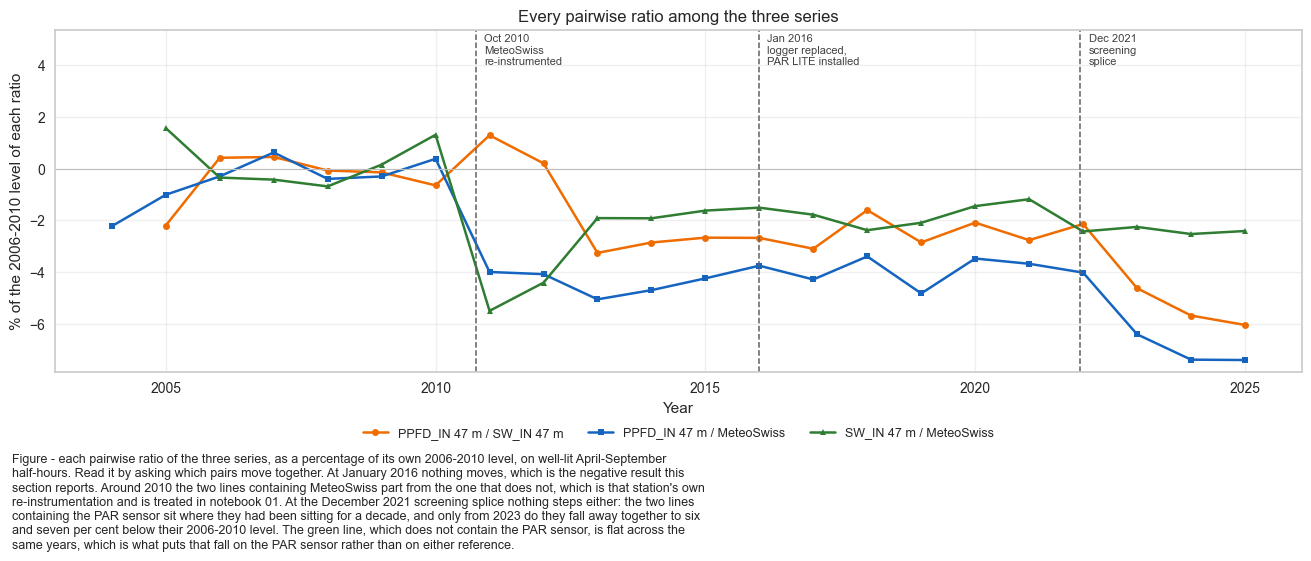

In [30]:
# The three ratios drawn together, with the dates this section is about marked on them. The tables
# above are single rows of this figure; the figure shows which changes are steps, which are drifts
# and which pairs move together, none of which two window means can convey. Drawn after the logger
# programs and the fieldbook have fixed the dates, so every marked date comes from a file.
fig, ax = plt.subplots(figsize=(13, 5.5), dpi=100, layout="constrained")
for _label, _colour, _marker in [(f'{PPFD_47} / {SW_47}', '#EF6C00', 'o'),
                                 (f'{PPFD_47} / {MS_SW}', '#1565C0', 's'),
                                 (f'{SW_47} / {MS_SW}', '#2E7D32', '^')]:
    ax.plot(relative.index, relative[_label], color=_colour, lw=1.8, marker=_marker, ms=5,
            label=_label)
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel(f"% of the {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level of each ratio")
ax.set_title("Every pairwise ratio among the three series")
ax.grid(alpha=0.3)

_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo, _hi + 0.34 * (_hi - _lo))
_top = ax.get_ylim()[1]
for _x, _text in [(2010.75, 'Oct 2010\nMeteoSwiss\nre-instrumented'),
                  (BREAK_YEAR, f'Jan {BREAK_YEAR}\nlogger replaced,\nPAR LITE installed'),
                  (SCREENING_YEAR - 0.05, f'Dec {SCREENING_YEAR - 1}\nscreening\nsplice')]:
    ax.axvline(_x, color='#616161', lw=1.1, ls='--')
    ax.text(_x + 0.15, _top - 0.15, _text, fontsize=8, color='#424242', va='top')
ax.legend(fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.13), frameon=False)

figcap(fig, f"each pairwise ratio of the three series, as a percentage of its own "
            f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level, on well-lit April-September "
            f"half-hours. Read it by asking which pairs move together. At January "
            f"{BREAK_YEAR} nothing moves, which is the negative result this section reports. "
            f"Around 2010 the two lines containing MeteoSwiss part from the one that does not, "
            f"which is that station's own re-instrumentation and is treated in notebook 01. At "
            f"the December {SCREENING_YEAR - 1} screening splice nothing steps either: the two "
            f"lines containing the PAR sensor sit where they had been sitting for a decade, and "
            f"only from {SCREENING_YEAR + 1} do they fall away together to six and seven per cent "
            f"below their {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level. The green line, which "
            f"does not contain the PAR sensor, is flat across the same years, which is what puts "
            f"that fall on the PAR sensor rather than on either reference.")

### 8️⃣ A falling sensor response since 2021

`PPFD_IN_T1_47_1` is **declining relative to both of the radiation references used here**, by
several per cent since 2021, and the record ends while it is still falling. This is a property of
the exported product, not of the gap-filling, and it is recorded here so that a user of the series
meets it in the documentation rather than in a trend.

The attribution is made in `RADIATION_SENSOR_CONTINUITY.ipynb`, which compares four radiation
sensors and shows that the two ratios containing this sensor move while the ratio between the
other two does not — which places the change on the PAR sensor rather than on either reference.
This step reproduces the size of it on this notebook's own data, and asserts it, so that the
statement cannot go stale while the notebook still runs.

The two references are independent of each other in the way that matters. MeteoSwiss Lägern is a
different institution's instrument 2.5 km away. The tower `SW_IN` is a different instrument with
different optics and its own calibration at the same height on the same mast — it shares this
sensor's tower, logger and maintenance history, but not the part of the measurement chain a
response drift lives in. A decline against both at once is a change here.

In [31]:
# The decline, measured on the same frame, the same controls and the same helper as every other
# step of this section. It is reported as a rate rather than as a step, because it has no date.
DECLINE_FROM = 2021
response_rel = relative[PPFD_PAIRS]

tabcap(f"the response of PPFD_IN relative to each radiation reference, as a percentage of its own "
       f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level. Only well-lit April-September half-hours "
       f"enter, as monthly medians averaged over calendar months, so neither the season nor how "
       f"sunny a year was can move a row")
display(response_rel.round(2))

_last = int(response_rel.index.max())
_fall = response_rel.loc[_last] - response_rel.loc[DECLINE_FROM]
print(f"\nchange in the response of PPFD_IN from {DECLINE_FROM} to {_last}:")
for _o, _v in _fall.items():
    print(f"  {_o:<28s} {_v:+.2f} %   "
          f"(and {response_rel.loc[_last, _o]:+.2f} % against {BASELINE_YEARS[0]}-"
          f"{BASELINE_YEARS[1]})")

# The product is exported as measured, so this is a limitation rather than something corrected.
# The assertion exists so the limitation cannot quietly stop being true, in either direction: if
# the decline reverses, the text above is wrong; if it deepens past a tenth of the signal, this
# notebook should not be exporting the series without saying considerably more.
assert (_fall < -2.0).all(), (
    "PPFD_IN no longer falls against both references since 2021 - the limitation described here "
    "and on the documentation page must be re-derived rather than left in place")
assert (response_rel.loc[_last] > -10.0).all(), (
    "the decline has passed 10 % of the baseline response - it is no longer a limitation to note "
    "in passing and the product needs a decision rather than a paragraph")
print("\nThe decline is present against both references and is still in progress at the end of "
      "the record.")

Table - the response of PPFD_IN relative to each radiation reference, as a percentage of its own
2006-2010 level. Only well-lit April-September half-hours enter, as monthly medians averaged over
calendar months, so neither the season nor how sunny a year was can move a row



,PPFD_IN 47 m / SW_IN 47 m,PPFD_IN 47 m / MeteoSwiss
YEAR,,
2004,NaN,-2.23
2005,-2.20,-1.01
2006,0.42,-0.30
2007,0.45,0.62
2008,-0.07,-0.40
2009,-0.15,-0.30
2010,-0.65,0.38
2011,1.29,-4.00
2012,0.20,-4.08



change in the response of PPFD_IN from 2021 to 2025:
  PPFD_IN 47 m / SW_IN 47 m    -3.28 %   (and -6.05 % against 2006-2010)
  PPFD_IN 47 m / MeteoSwiss    -3.72 %   (and -7.40 % against 2006-2010)

The decline is present against both references and is still in progress at the end of the record.


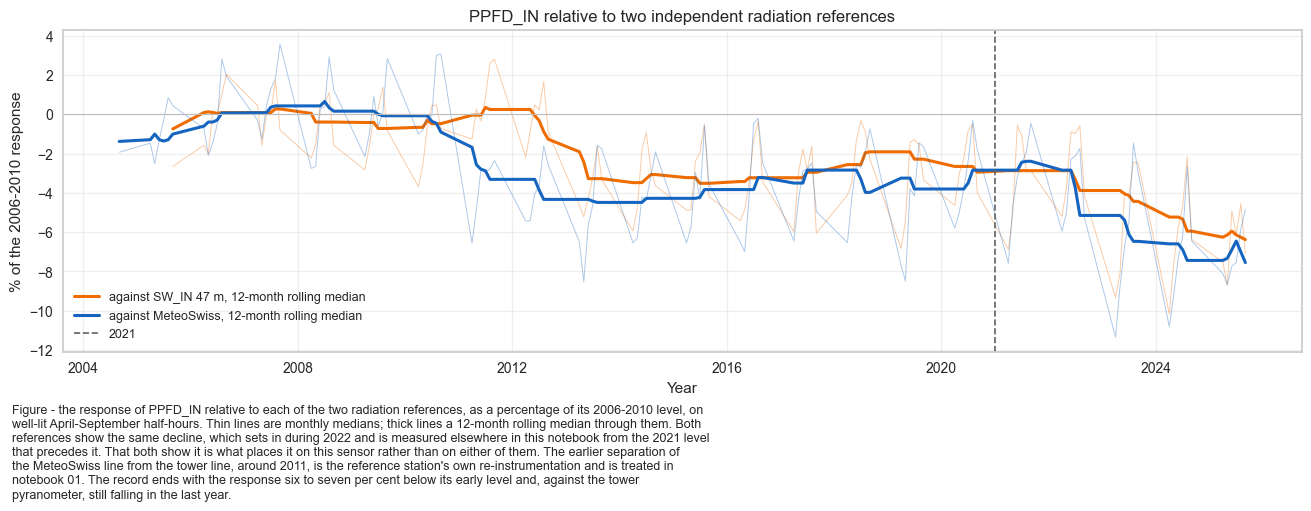

In [32]:
# Drawn as monthly medians behind a 12-month rolling median: this is a drift, not a step, and a
# yearly table cannot show whether it has levelled off. It has not.
fig, ax = plt.subplots(figsize=(13, 5), dpi=100, layout="constrained")
for _o, _colour in [(SW_47, '#EF6C00'), (MS_SW, '#1565C0')]:
    _j = rad.loc[USABLE, [PPFD_47, _o]].dropna()
    _j = _j[(_j[PPFD_47] > MIN_IRRADIANCE) & (_j[_o] > MIN_IRRADIANCE)]
    _r = (_j[PPFD_47] / _j[_o])
    _monthly = _r.resample('MS').median()
    _monthly = _monthly[_r.resample('MS').count() >= 100]
    _rel = 100 * (_monthly / _monthly.loc[f'{BASELINE_YEARS[0]}':f'{BASELINE_YEARS[1]}'].median() - 1)
    ax.plot(_rel.index, _rel, color=_colour, lw=0.7, alpha=0.35)
    ax.plot(_rel.index, _rel.rolling(12, center=True, min_periods=6).median(), color=_colour,
            lw=2.2, label=f'against {_o}, 12-month rolling median')
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.axvline(pd.Timestamp(f'{DECLINE_FROM}-01-01'), color='#616161', lw=1.2, ls='--',
           label=f'{DECLINE_FROM}')
ax.set_xlabel("Year")
ax.set_ylabel(f"% of the {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} response")
ax.set_title("PPFD_IN relative to two independent radiation references")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower left')
figcap(fig, "the response of PPFD_IN relative to each of the two radiation references, as a "
            "percentage of its 2006-2010 level, on well-lit April-September half-hours. Thin "
            "lines are monthly medians; thick lines a 12-month rolling median through them. Both "
            "references show the same decline, which sets in during 2022 and is measured "
            "elsewhere in this notebook from the 2021 level that precedes it. That both show it "
            "is what places it on this sensor rather than on either of them. The earlier "
            "separation of the MeteoSwiss line from the tower line, around 2011, is the reference "
            "station's own re-instrumentation and is treated in notebook 01. The record ends "
            "with the response six to seven per cent below its early level and, against the tower "
            "pyranometer, still falling in the last year.")

::: {.callout-warning title="Known limitation of this product"}

`PPFD_IN_T1_47_1` is exported **as measured**. No correction is applied for the decline above, for
two reasons: it develops over years rather than stepping at a date, so there is no boundary at
which a correction could be applied; and no maintenance record identifies a cause, so any
correction would be a rescaling towards a reference rather than a repair of a known fault.

The practical consequences:

- A **trend** computed over the last years of this record, or across 2021, contains the sensor's
  own decline as well as any change in the light. The size of it is in the table above.
- Comparisons **within** a year, and the relation between `PPFD_IN` and the other radiation
  variables at a given time, are unaffected.
- Gap-filled records inherit the state of the sensor at the time they were filled, because the
  model is trained on the measurements around them. They neither add the bias nor remove it.

The likeliest cause of a falling response in a PAR sensor left in the field for twenty years is
the sensor itself — soiling, or ageing of its diffuser and its detectors. A calibration or a
replacement would settle it, and until one happens the decline can only be reported.

:::

#### What this section settles

`PPFD_IN_T1_47_1` is **one instrument over the whole record** — the Delta-T sunshine sensor, hung
at 47 m in August 2004 and never replaced — read through the same conversion by two acquisition
systems. It is **homogeneous across the January 2016 changeover** and across the December 2021
screening splice, so no correction is applied for either and no `_HOMOGENIZED` column is exported,
because there is nothing to homogenise. That absence is itself a claim, and the assertions above are what
keep it true.

What the section does not settle is the decline. It is real, it is on this sensor, it is not
corrected, and it is the first thing the documentation page for this variable tells a reader.

## 🟥 Gap-filling

### Method

There is no `PPFD_IN`-specific gap-filling class in diive, so this uses the general `XGBoostTS`
with an explicit `FeatureEngineer`, as notebook `02` does for `TA`. Two settings differ from the
temperature case, both because `PPFD_IN` is a radiation quantity:

- **`below_zero='zero'`** — negative predictions are clipped. Temperature can be negative,
  photon flux cannot.
- **Nighttime gaps are set to zero by physics** after modelling, and flagged `3`. There is no
  photosynthetically active radiation at night, so a modelled value there would be noise around a
  known answer. This mirrors what `SWINGapFillerXGBoost` does internally in notebook `01`.

Otherwise the configuration follows notebook `02`: no lag features (a lag of a gappy driver
demotes records to the timestamp-only fallback), `SW_IN_POT` excluded from the rolling and EMA
stages (smoothing a deterministic timestamp curve adds nothing), SHAP capped at 10,000 rows, and
short daytime gaps filled by interpolation afterwards and flagged `4`.

In [33]:
SHAP_MAX_ROWS = 10_000


def short_gap_mask(missing: pd.Series, limit: int) -> pd.Series:
    """True where `missing` is set AND its whole run is at most `limit` records long.

    Takes a boolean gap mask rather than the series itself, so the caller can pass the
    mask from before the nighttime offset correction.
    """
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def gapfill_ppfd(target: pd.Series,
                 drivers: pd.DataFrame,
                 swinpot: pd.Series,
                 original_gaps: pd.Series,
                 interpolate_limit: int = 2,
                 reduce_features: bool = True,
                 verbose: int = 1):
    """Gap-fill PPFD with XGBoost, force nighttime to zero, interpolate short daytime gaps.

    `original_gaps` must be the gap mask from BEFORE the nighttime offset correction:
    that correction zeroes every nighttime record including the missing ones, so
    `target.isna()` here would report no nighttime gaps at all and label them as measured.

    Returns (model, gapfilled, flag).
    """
    daytime = swinpot >= NIGHTTIME_THRESHOLD

    input_df = pd.concat([target, drivers], axis=1)
    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],
        features_rolling=[4, 8, 24, 48],
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],
        features_ema=[6, 24],
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df, target_col=target.name, verbose=verbose,
        below_zero='zero',           # photon flux cannot be negative
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000, max_depth=6, early_stopping_rounds=20,
        random_state=42, n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    # Physics beats the model at night: no incoming PAR after sunset.
    night_gaps = original_gaps & ~daytime
    gapfilled[night_gaps] = 0.0
    flag[night_gaps] = 3
    print(f"Nighttime gaps set to 0: {int(night_gaps.sum()):,}")

    # Short DAYTIME gaps only - a night is already handled above. The run-length search
    # uses the pre-correction mask for the same reason as above.
    if interpolate_limit:
        short = short_gap_mask(original_gaps, interpolate_limit) & daytime
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

### Run gap-filling

In [34]:
%%time

gf_ppfd, gapfilled_ppfd, flag_ppfd = gapfill_ppfd(
    target=ppfd_2004_2025[TARGET],
    drivers=drivers,
    swinpot=drivers['SW_IN_POT'],
    original_gaps=PPFD_ORIGINAL_GAPS,  # from BEFORE the offset correction, see there
)

Features: 46 over 385,728 records


! Some features are incomplete (<385728 values): SW_IN_LAE_MS (384126), .SW_IN_LAE_MS_MEAN4 
(384161), .SW_IN_LAE_MS_SD4 (384161), .SW_IN_LAE_MS_MEAN8 (384186), .SW_IN_LAE_MS_SD8 (384186), 
.SW_IN_LAE_MS_MEAN24 (384232), .SW_IN_LAE_MS_SD24 (384232), .SW_IN_LAE_MS_MEAN48 (384239), 
.SW_IN_LAE_MS_SD48 (384239), .SW_IN_LAE_MS_ROLLMEDIAN4 (384161), .SW_IN_LAE_MS_ROLLMEDIAN8 (384186),
.SW_IN_LAE_MS_ROLLMEDIAN24 (384232), .SW_IN_LAE_MS_ROLLMEDIAN48 (384239), .SW_IN_LAE_MS_EMA6 
(384239), .SW_IN_LAE_MS_EMA24 (384239)

! Not all target values can be predicted based on the full model.

> ++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', 
'.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', 
'.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] (ONLY 
FALLBACK)

Nighttime gaps set to 0: 7,543
Short-gap interpolation: 87 records
CPU times: total: 34min 7s
Wall time: 2min 32s


### Results: scores and feature importances

In [35]:
tabcap("the held-out scores of the gap-filling model, as diive reports them. These are computed on records the model never saw during training")
display(pd.Series(gf_ppfd.results.scores_traintest))
tabcap("how many records each provenance code accounts for, before the export checks repeat the count on the finished frame")
display(flag_ppfd.value_counts().sort_index().rename(index=FLAG_LEGEND))

Table - the held-out scores of the gap-filling model, as diive reports them. These are computed on
records the model never saw during training



mae      8.161312e+00
medae    1.427741e+00
mse      5.030504e+02
rmse     2.242879e+01
mape     1.511145e+15
maxe     1.262649e+03
r2       9.978676e-01
dtype: float64

Table - how many records each provenance code accounts for, before the export checks repeat the
count on the finished frame



FLAG_PPFD_IN_T1_47_1_ISFILLED
0 = observed                                                                  369124
1 = gap-filled by the XGBoost model                                             8374
2 = gap-filled by the timestamp-only fallback model (a driver was missing)       600
3 = nighttime gap, set to zero by physics                                       7543
4 = gap-filled by linear interpolation (short gap)                                87
Name: count, dtype: int64

Table - driver importance for the PPFD_IN_T1_47_1 model, as the gap-filler reports it



,SHAP_IMPORTANCE,SHAP_SD
SW_IN_T1_47_1_gfXG,286.999939,237.178268
SW_IN_LAE_MS,64.656197,84.092285
SW_IN_POT,11.911252,7.140404
.DOY_COS,6.963439,6.024593
.SW_IN_T1_47_1_gfXG_MEAN48,6.896213,6.728474
.YEARWEEK,5.796655,6.845006
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN4,5.464215,6.031366
.SW_IN_T1_47_1_gfXG_MEAN4,5.384974,3.335186
.SW_IN_LAE_MS_MEAN48,4.565189,4.930974
.SW_IN_LAE_MS_SD48,3.963548,3.240794


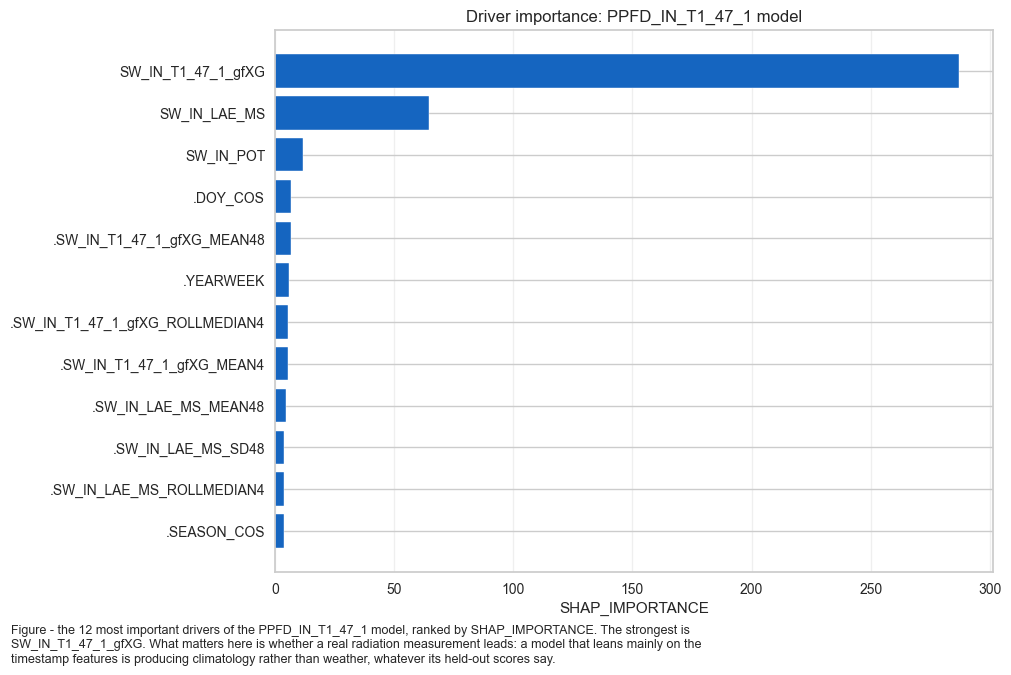

In [36]:
tabcap("driver importance for the PPFD_IN_T1_47_1 model, as the gap-filler reports it")
display(gf_ppfd.results.feature_importances)
plot_feature_importances(gf_ppfd.results, label="PPFD_IN_T1_47_1 model");

#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything implausible there is worth following
up, because it is invisible in the combined series.

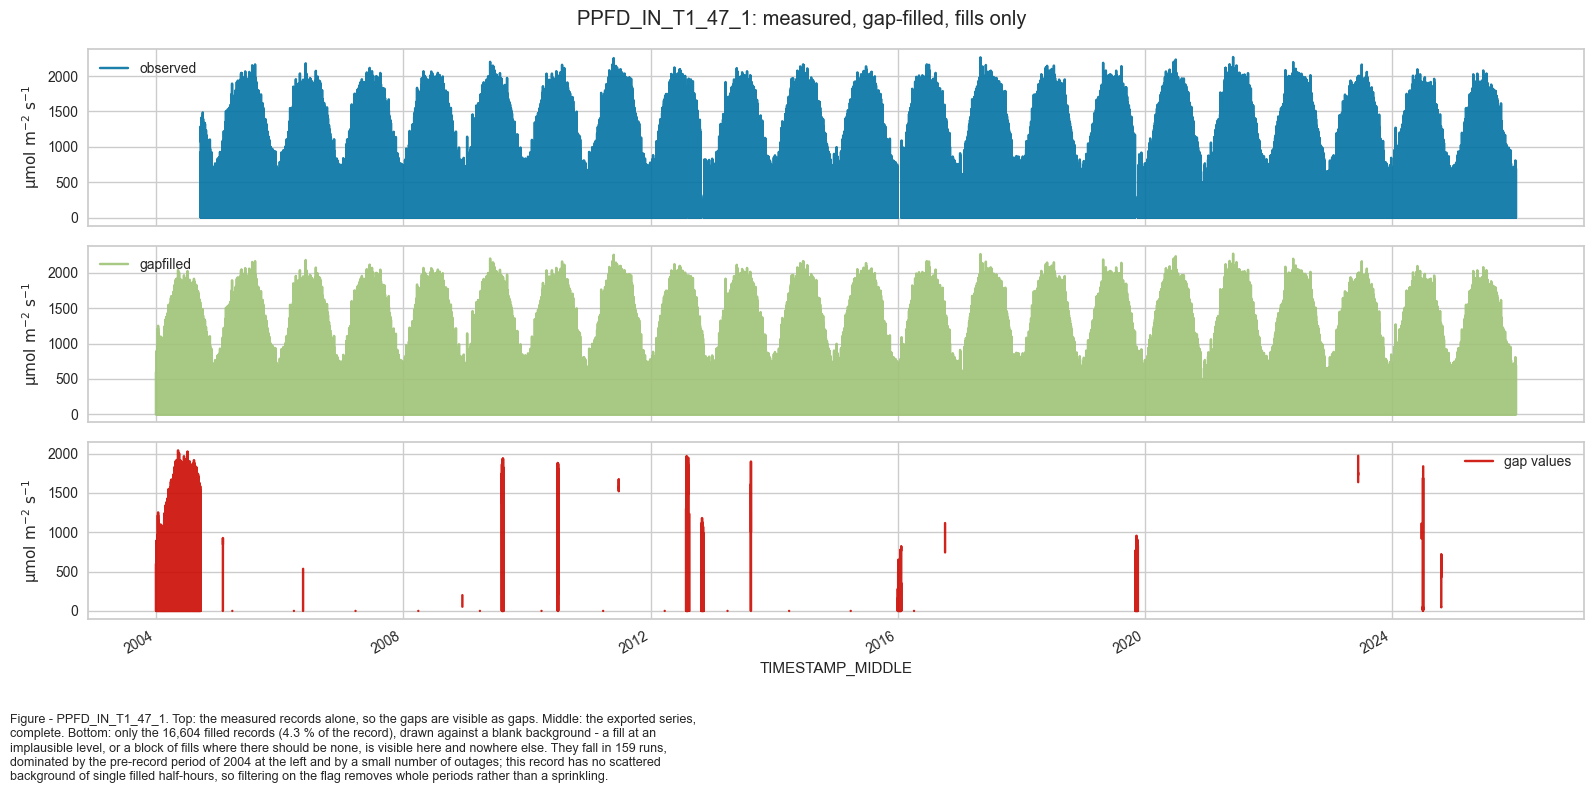

In [37]:
plot_gapfill_panels(gapfilled_ppfd, flag_ppfd, label=f"{TARGET}");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this shows whether it is actually any good.

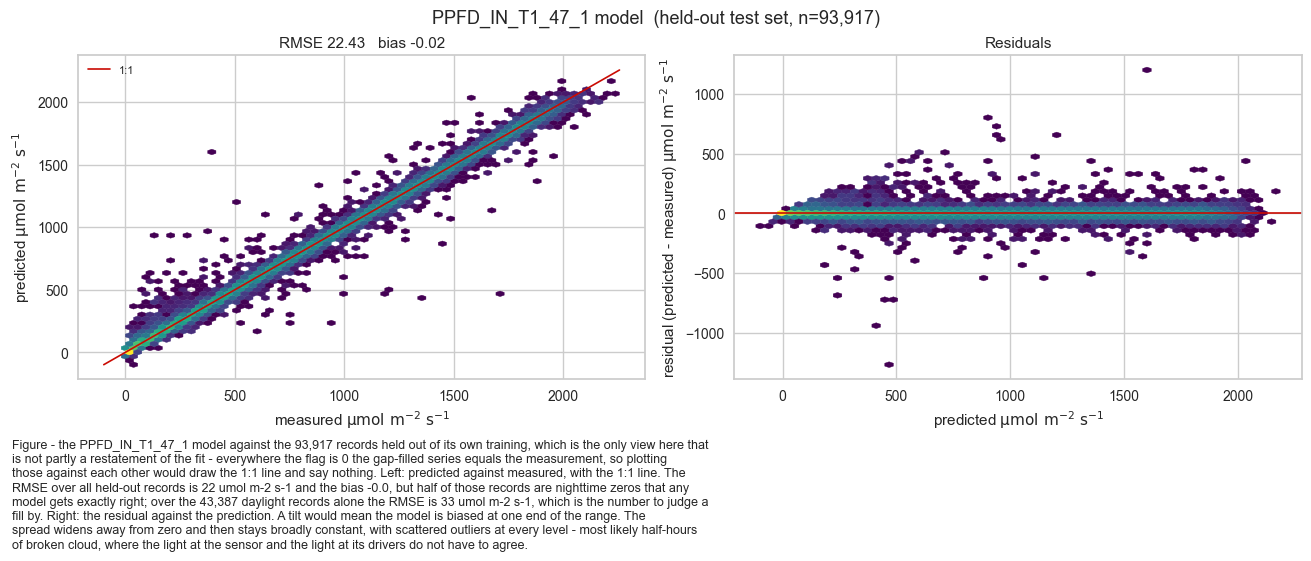

In [38]:
plot_pred_vs_measured(gf_ppfd, label=f"{TARGET} model");

***

## ➡️ Prepare dataframe for export

In [39]:
VALCOL = f"{TARGET}_gfXG"
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"

export_df = pd.concat([gapfilled_ppfd, flag_ppfd], axis=1)
tabcap("the frame that is exported: the gap-filled series and the provenance code that travels with it")
export_df

Table - the frame that is exported: the gap-filled series and the provenance code that travels with
it



,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete, non-negative, on a continuous 30MIN index
with no duplicates, and every record must carry a flag.

`FLAG_PPFD_IN_T1_47_1_ISFILLED` travels with the product so downstream notebooks can tell measured
from filled records.

In [40]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f}")

tabcap("the provenance of every record in the exported product. Code 3 is a nighttime gap set to zero by physics rather than an estimate, so codes 0 and 3 together are the share of the product that no model produced")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts,
                      '%': (100 * _counts / len(export_df)).round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

tabcap("summary statistics of the exported product")
export_df.describe()

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0
Min / max:       0.00 / 2271.09
Table - the provenance of every record in the exported product. Code 3 is a nighttime gap set to
zero by physics rather than an estimate, so codes 0 and 3 together are the share of the product that
no model produced



,count,%
FLAG_PPFD_IN_T1_47_1_ISFILLED,,
0 = observed,369124,95.70
1 = gap-filled by the XGBoost model,8374,2.17
2 = gap-filled by the timestamp-only fallback model (a driver was missing),600,0.16
"3 = nighttime gap, set to zero by physics",7543,1.96
4 = gap-filled by linear interpolation (short gap),87,0.02


Measured: 95.70%  |  Filled: 4.30%
Table - summary statistics of the exported product



,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,292.152648,0.084388
std,488.310415,0.447679
min,0.000000,0.000000
25%,0.000000,0.000000
50%,6.523007,0.000000
75%,380.219096,0.000000
max,2271.086339,4.000000


### Fill statistics per year

**Note on 2004.** `PPFD_IN` measurements only start on 20 September 2004, so everything before
that is modelled. Those records are filled from the gap-filled `SW_IN` of notebook `01`, which is
itself reconstructed for 2004 from the NABEL sensor. They are therefore a fill built on a fill and
carry the uncertainty of both steps. The flag marks them, so they can be excluded where that
matters.

Table - records per year and provenance code for PPFD_IN_T1_47_1_gfXG. Every record carries a code,
so the rows sum to the number of half-hours in each year



,0 = observed,1 = gap-filled by the XGBoost model,2 = gap-filled by the timestamp-only fallback model (a driver was missing),"3 = nighttime gap, set to zero by physics",4 = gap-filled by linear interpolation (short gap)
year,,,,,
2004,4922,6518,571,5556,1
2005,17485,10,0,17,8
2006,17493,5,0,14,8
2007,17507,0,0,6,7
2008,17548,4,0,8,8
2009,17036,292,0,184,8
2010,17351,109,0,55,5
2011,17499,10,0,6,5
2012,16310,627,29,596,6


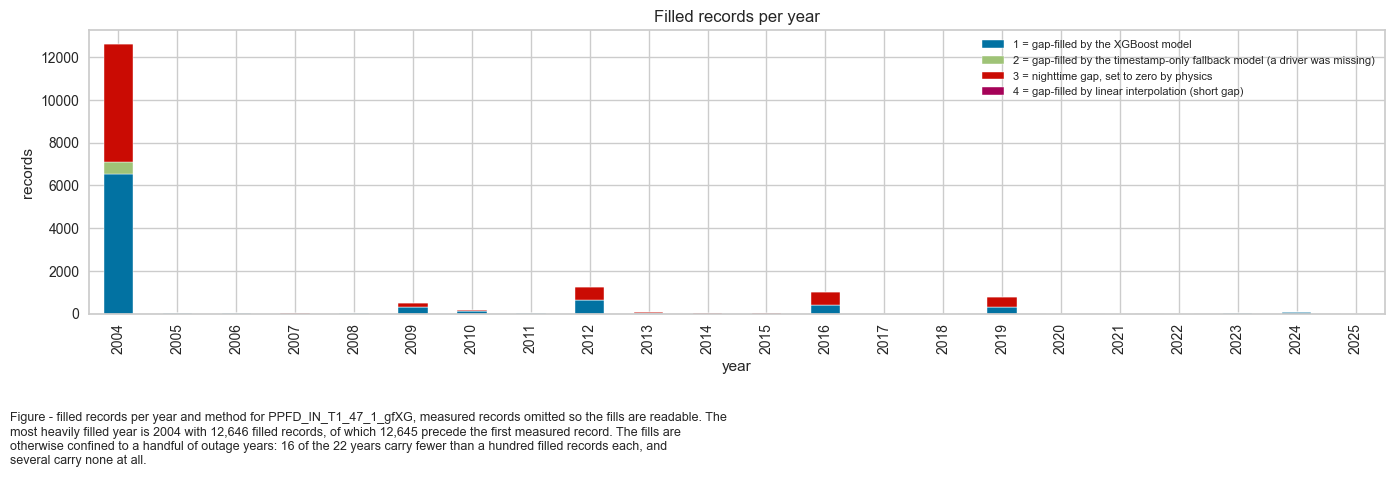

In [41]:
fill_stats_by_year(export_df[FLAGCOL], label=VALCOL)

### Gap-filling overview

Where the fills sit in the record, and whether they behave like the measured data. In the monthly
means panel the two lines should track each other; a systematic gap between them would mean the
fills are biased relative to the measurements.

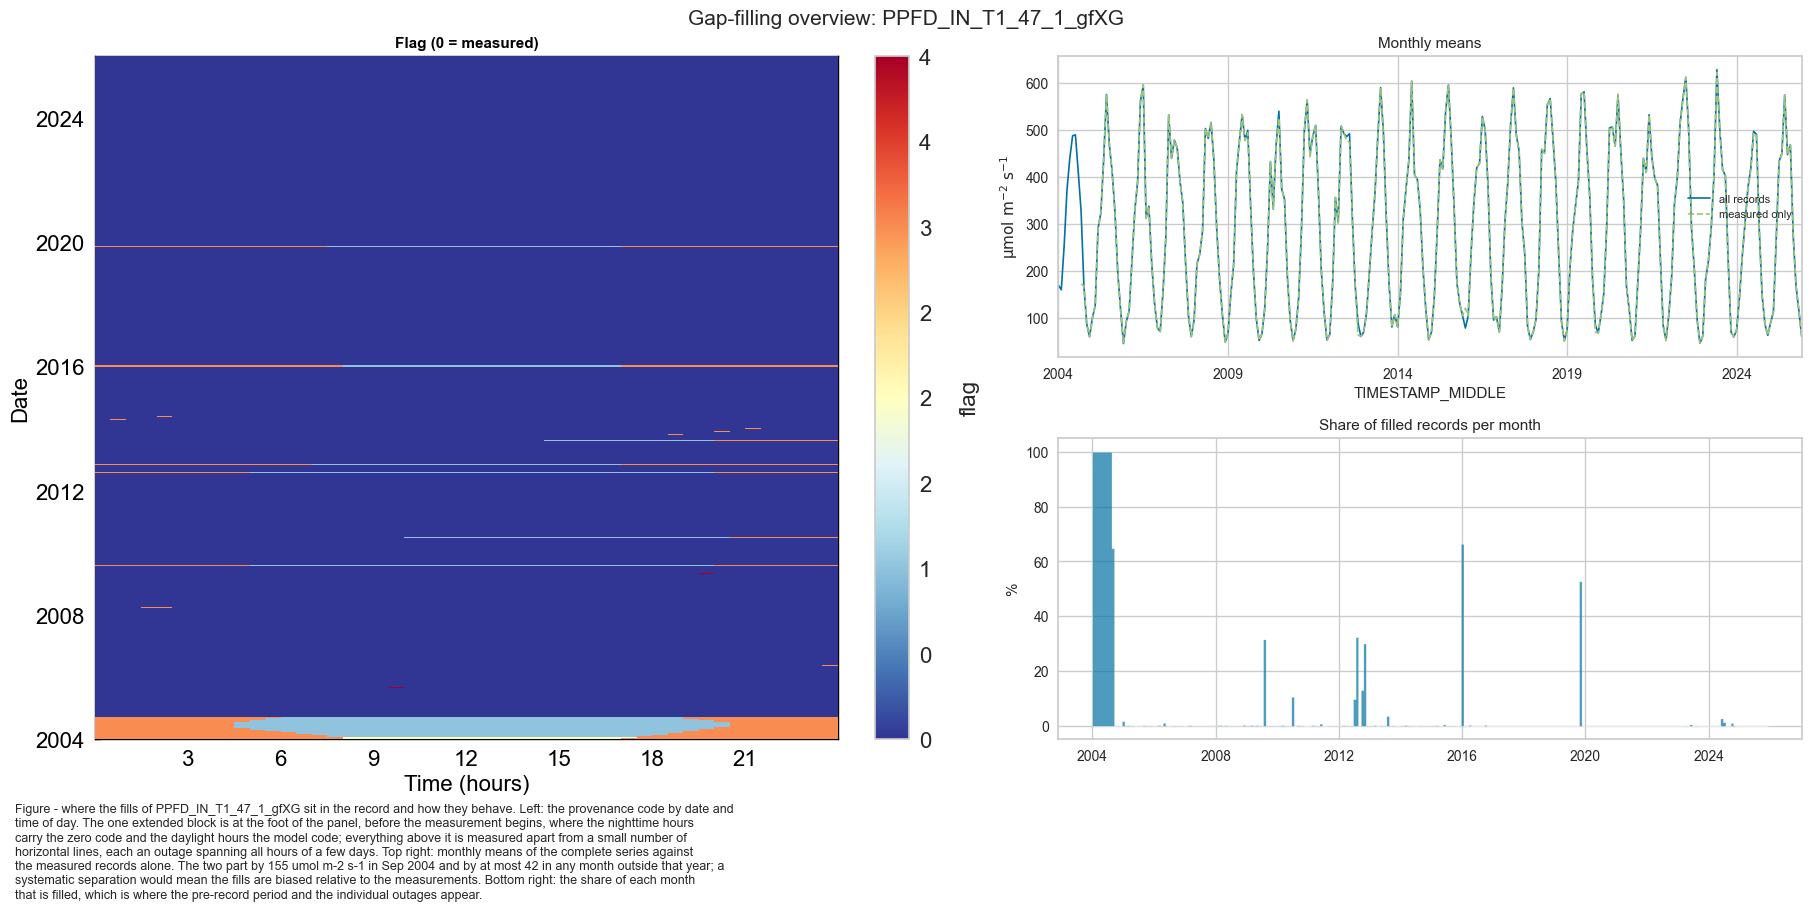

In [42]:
plot_fill_overview(export_df[VALCOL], export_df[FLAGCOL], label=VALCOL);

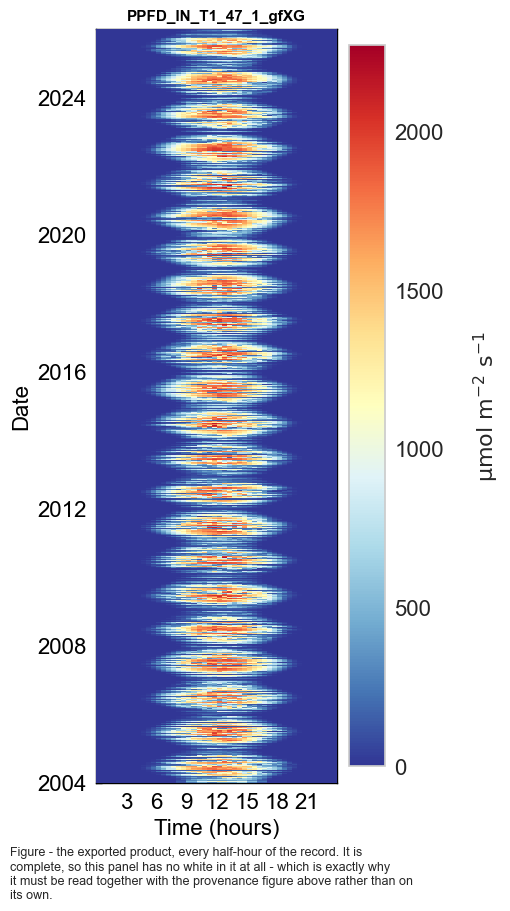

In [43]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))
figcap(fig, "the exported product, every half-hour of the record. It is complete, so this "
            "panel has no white in it at all - which is exactly why it must be read "
            "together with the provenance figure above rather than on its own.")

### The exported product

Three views of the finished series that the diagnostics above do not give: the shape of the
average day through the year, whether the values are physically possible, and whether the filled
records have the same *spread* as the measured ones. The last of those is the one a comparison of
means cannot make — a fill with the right mean and no weather in it passes a level test and fails
this one.

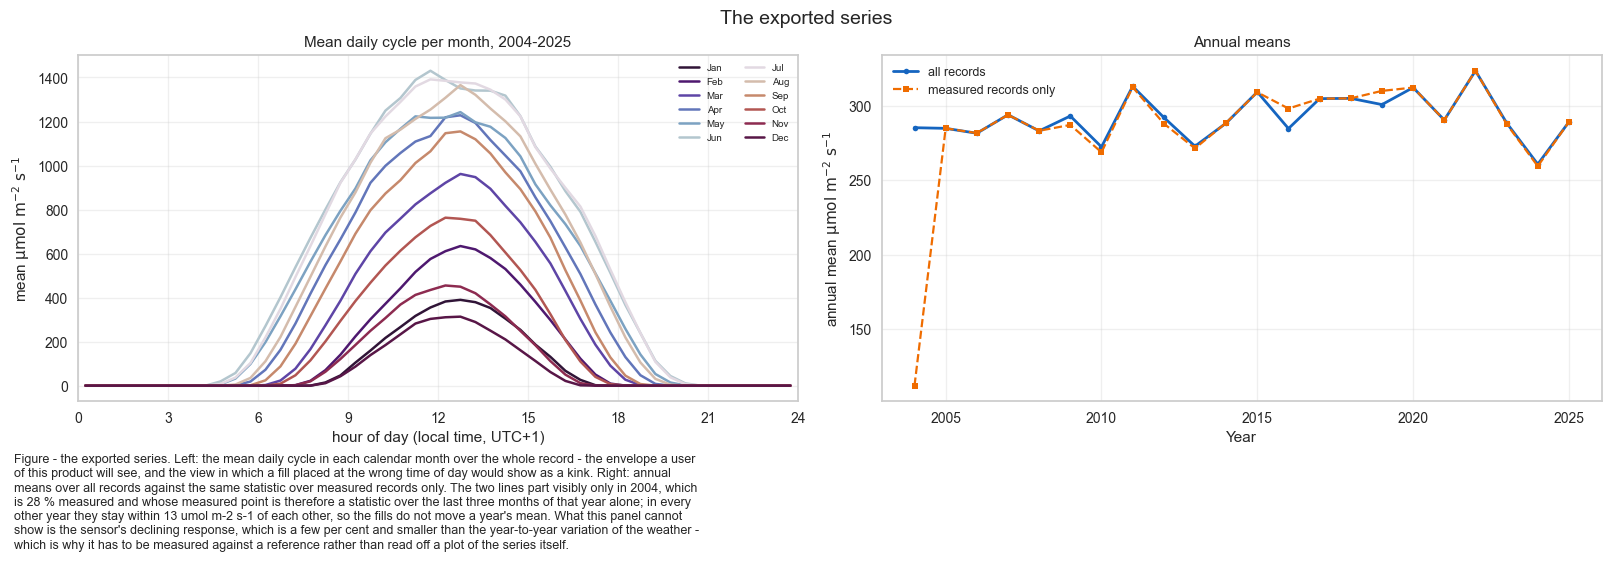

In [44]:
# The average day, month by month, and the annual cycle. This is the shape a user of the product
# will actually see, and a fill that sat at the wrong time of day would distort it.
_pot_out = dv.variables.potrad(timestamp_index=export_df.index, lat=SITE_LAT, lon=SITE_LON,
                               utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_d = pd.DataFrame({'v': export_df[VALCOL], 'flag': export_df[FLAGCOL], 'pot': _pot_out})
_d['hour'] = _d.index.hour + _d.index.minute / 60
_d['month'] = _d.index.month

fig, axs = plt.subplots(ncols=2, figsize=(16, 5.5), dpi=100, layout='constrained')
fig.suptitle('The exported series', fontsize=14)

_comp = _d.pivot_table(index='hour', columns='month', values='v', aggfunc='mean')
_cmap = plt.get_cmap('twilight_shifted')
for _m in _comp.columns:
    axs[0].plot(_comp.index, _comp[_m], color=_cmap((_m - 1) / 12), lw=1.8,
                label=pd.Timestamp(2020, _m, 1).strftime('%b'))
axs[0].set_xlabel('hour of day (local time, UTC+1)')
axs[0].set_ylabel(r'mean $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
axs[0].set_xlim(0, 24)
axs[0].set_xticks(range(0, 25, 3))
axs[0].set_title('Mean daily cycle per month, 2004-2025', fontsize=11)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=7, ncol=2)

_ann = _d['v'].resample('YE').mean()
_ann.index = _ann.index.year
_ann_meas = _d['v'].where(_d['flag'] == 0).resample('YE').mean()
_ann_meas.index = _ann_meas.index.year
axs[1].plot(_ann.index, _ann, color='#1565C0', lw=2, marker='o', ms=4, label='all records')
axs[1].plot(_ann_meas.index, _ann_meas, color='#EF6C00', lw=1.6, ls='--', marker='s', ms=4,
            label='measured records only')
axs[1].set_xlabel('Year')
axs[1].set_ylabel(r'annual mean $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
axs[1].set_title('Annual means', fontsize=11)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=9)

_meas_share_2004 = 100 * (_d.loc['2004', 'flag'] == 0).mean()
_ann_gap = (_ann - _ann_meas).abs().drop(index=2004).max()
figcap(fig, f"the exported series. Left: the mean daily cycle in each calendar month over the "
            f"whole record - the envelope a user of this product will see, and the view in which "
            f"a fill placed at the wrong time of day would show as a kink. Right: annual means "
            f"over all records against the same statistic over measured records only. The two "
            f"lines part visibly only in 2004, which is {_meas_share_2004:.0f} % measured and "
            f"whose measured point is therefore a statistic over the last three months of that "
            f"year alone; in every other year they stay within "
            f"{_ann_gap:.0f} umol m-2 s-1 of each other, so the fills do not move a year's mean. "
            f"What this panel cannot show is the sensor's declining response, which is a few per "
            f"cent and smaller than the year-to-year variation of the weather - which is why it "
            f"has to be measured against a reference rather than read off a plot of the series "
            f"itself.")

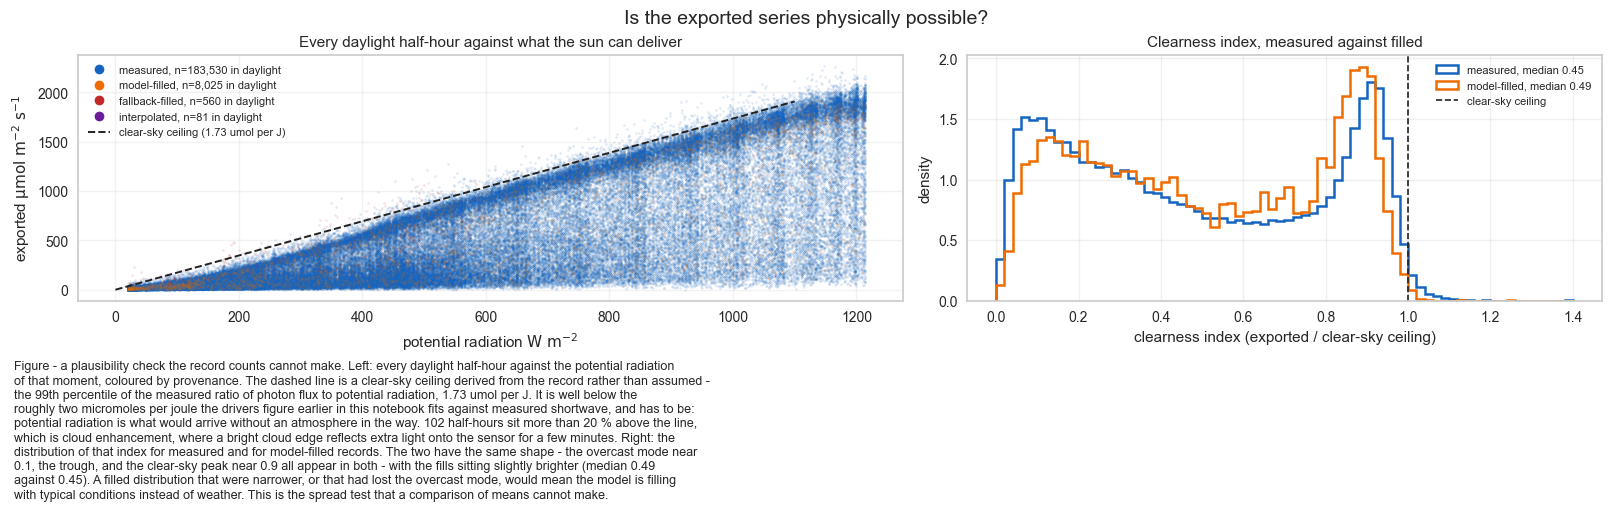

In [45]:
# A plausibility check the flag counts cannot make, and the spread test a comparison of means
# cannot make. Photon flux is not measured in the same unit as the potential radiation it is
# limited by, so the ceiling is not the 1:1 line here as it is in notebook 01: it is the
# photon-to-energy ratio of the solar spectrum, about 2 umol per joule, which is derived from the
# clear-sky records themselves rather than quoted.
_lit = _d[_d['pot'] > 20]
CLEAR = _lit[(_lit['flag'] == 0) & (_lit['v'] / _lit['pot'] > 0)]
PHOTON_RATIO = float((CLEAR['v'] / CLEAR['pot']).quantile(0.99))   # umol per J of shortwave
_kt = (_d['v'] / (_d['pot'] * PHOTON_RATIO)).where(_d['pot'] > 20)

fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout='constrained',
                        width_ratios=[1.3, 1])
fig.suptitle('Is the exported series physically possible?', fontsize=14)

_sample = _lit.sample(min(120_000, len(_lit)), random_state=42)
for _flagval, _colour, _lab in [(0, '#1565C0', 'measured'), (1, '#EF6C00', 'model-filled'),
                                (2, '#C62828', 'fallback-filled'),
                                (4, '#6A1B9A', 'interpolated')]:
    _s = _sample[_sample['flag'] == _flagval]
    if len(_s):
        axs[0].scatter(_s['pot'], _s['v'], s=2, alpha=0.12, color=_colour, rasterized=True)
        axs[0].plot([], [], 'o', color=_colour,
                    label=f'{_lab}, n={int((_lit["flag"] == _flagval).sum()):,} in daylight')
axs[0].plot([0, 1100], [0, 1100 * PHOTON_RATIO], color='#212121', lw=1.4, ls='--',
            label=f'clear-sky ceiling ({PHOTON_RATIO:.2f} umol per J)')
axs[0].set_xlabel(r'potential radiation $\mathrm{W\ m^{-2}}$')
axs[0].set_ylabel(r'exported $\mathrm{\mu mol\ m^{-2}\ s^{-1}}$')
axs[0].set_title('Every daylight half-hour against what the sun can deliver', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')
axs[0].grid(alpha=0.25)

for _flagval, _colour, _lab in [(0, '#1565C0', 'measured'), (1, '#EF6C00', 'model-filled')]:
    _s = _kt[_d['flag'] == _flagval].dropna()
    if len(_s):
        axs[1].hist(_s.clip(0, 1.4), bins=np.linspace(0, 1.4, 71), histtype='step', lw=1.8,
                    density=True, color=_colour, label=f'{_lab}, median {_s.median():.2f}')
axs[1].axvline(1.0, color='#212121', lw=1.2, ls='--', label='clear-sky ceiling')
axs[1].set_xlabel('clearness index (exported / clear-sky ceiling)')
axs[1].set_ylabel('density')
axs[1].set_title('Clearness index, measured against filled', fontsize=11)
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3)

_over = int((_kt > 1.2).sum())
_kt_meas = _kt[_d['flag'] == 0].dropna()
_kt_fill = _kt[_d['flag'] == 1].dropna()
figcap(fig, f"a plausibility check the record counts cannot make. Left: every daylight half-hour "
            f"against the potential radiation of that moment, coloured by provenance. The dashed "
            f"line is a clear-sky ceiling derived from the record rather than assumed - the 99th "
            f"percentile of the measured ratio of photon flux to potential radiation, "
            f"{PHOTON_RATIO:.2f} umol per J. It is well below the roughly two micromoles per "
            f"joule the drivers figure earlier in this notebook fits against measured shortwave, and has to be: "
            f"potential radiation is what would arrive without an atmosphere in the way. "
            f"{_over:,} half-hours sit more than 20 % above the line, which is cloud enhancement, "
            f"where a bright cloud edge reflects extra light onto the sensor for a few minutes. "
            f"Right: the distribution of that index for measured and for model-filled records. "
            f"The two have the same shape - the overcast mode near 0.1, the trough, and the "
            f"clear-sky peak near 0.9 all appear in both - with the fills sitting slightly "
            f"brighter (median {_kt_fill.median():.2f} against {_kt_meas.median():.2f}). A filled "
            f"distribution that were narrower, or that had lost the overcast mode, would mean the "
            f"model is filling with typical conditions instead of weather. This is the spread "
            f"test that a comparison of means cannot make.")

***

## 💾 Save to file

In [46]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet (0.362 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [47]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int((_written[FLAGCOL] == 0).sum()):,} "
      f"({100 * (_written[FLAGCOL] == 0).mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.3f} umol m-2 s-1")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} umol m-2 s-1")

assert list(_written.columns) == [VALCOL, FLAGCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written.index.equals(export_df.index), "index changed on write"
# The product is documented as complete and non-negative. Both claims are checked here on the file
# itself rather than on the frame that was handed to the writer.
assert _written[VALCOL].notna().all(), "the written file has gaps, but this product is exported complete"
assert float(_written[VALCOL].min()) >= 0, "negative photon flux in the written file"
assert float(_written[VALCOL].max()) < 3000, "photon flux above anything this latitude can deliver"
assert (set(_written[FLAGCOL].unique()) <= set(FLAG_LEGEND)), (
    "the written file carries a flag code that FLAG_LEGEND does not document")
print()
print("Written file verified.")

tabcap("the yearly median and measured share of the column as it was actually written to the "
       "parquet file, read back from disk rather than taken from the frame in memory")
display(pd.DataFrame({
    'yearly median (umol m-2 s-1)': _written[VALCOL].groupby(_written.index.year).median().round(3),
    'measured (%)': (100 * (_written[FLAGCOL] == 0)).groupby(_written.index.year).mean().round(1),
}))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet (0.024 seconds).

columns:   ['PPFD_IN_T1_47_1_gfXG', 'FLAG_PPFD_IN_T1_47_1_ISFILLED']
index:     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
measured:  369,124 (95.70%)
median:    6.523 umol m-2 s-1
min / max: 0.000 / 2271.086 umol m-2 s-1

Written file verified.
Table - the yearly median and measured share of the column as it was actually written to the parquet
file, read back from disk rather than taken from the frame in memory



,yearly median (umol m-2 s-1),measured (%)
TIMESTAMP_MIDDLE,,
2004,8.496,28.0
2005,7.216,99.8
2006,7.464,99.8
2007,7.085,99.9
2008,7.010,99.9
2009,6.395,97.2
2010,5.951,99.0
2011,6.066,99.9
2012,5.418,92.8


***

## End of notebook.

In [48]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-31 13:04:34
Finished: 2026-07-31 13:08:39
Runtime:  00:04:05 (hh:mm:ss)
